# EDA & Business Insights — E-Commerce Customer Analytics
 
**Stage**: Exploratory Data Analysis (EDA)  
**Goal**

| # | Business Problem |
|---|---|
| 1 | Unable to identify the most valuable customers |
| 2 | Unable to identify customers who are likely to churn |
| 3 | Unable to determine how to allocate the marketing budget effectively |

## 0. Setup & Data Load

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global Style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'font.size'         : 11,
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : True,
    'axes.spines.bottom': True,
    'axes.grid'         : False,
    'axes.linewidth'    : 0.8,
    'xtick.major.size'  : 4,
    'ytick.major.size'  : 4,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
})

# ── Color Palette ───────────────────────────────────────────────────────────
BLUE    = "#2563EB"
RED     = "#DC2626"
GREEN   = "#16A34A"
AMBER   = "#D97706"
GRAY    = "#94A3B8"
LGRAY   = "#E2E8F0"
CAT6 = [BLUE, AMBER, GREEN, "#7C3AED", "#0891B2", GRAY]

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)

import os
os.makedirs("Output/plots", exist_ok=True)
print("✅ Libraries loaded")


✅ Libraries loaded


In [22]:
import pandas as pd
import numpy as np

# ── Load master_df từ Feature Engineering ───────────────────────────────────
df = pd.read_csv("Dataset/Cleaned_data/master_df.csv", parse_dates=["Transaction_Date"])

# ── Tái lập các cột thời gian ──────────────────────────────────────────────
df["Month_Num"] = df["Transaction_Date"].dt.month
df["Year"]      = df["Transaction_Date"].dt.year
df["YearMonth"] = df["Transaction_Date"].dt.to_period("M").astype(str)
df["DayName"]   = df["Transaction_Date"].dt.day_name()
df["Month"]     = df["Transaction_Date"].dt.strftime("%b")

# Season mapping
season_map = {12:"Winter", 1:"Winter", 2:"Winter",
              3:"Spring", 4:"Spring", 5:"Spring",
              6:"Summer", 7:"Summer", 8:"Summer",
              9:"Fall", 10:"Fall", 11:"Fall"}
df["Season"] = df["Month_Num"].map(season_map)

# ── Tính toán các Metric chuẩn ─────────────────────────────────────────────

# 1. Discount_Amount: Chỉ tính khi Coupon_Status là 'Used'
df["Discount_Amount"] = np.where(
    df["Coupon_Status"] == "Used",
    df["Quantity"] * df["Avg_Price"] * df["Discount_pct"],
    0
)

# 2. total_revenue: Dùng để đối chiếu với ABC (Doanh thu đã trừ discount + thuế)

df["total_revenue"] = (
    df["Quantity"] * df["Avg_Price"]
    * (1 - df["Discount_pct"])
    +df["Delivery_Charges"]
)

# 3. Invoice: Số tiền thực tế khách trả (bao gồm cả phí vận chuyển)
df["Invoice"] = df["total_revenue"] + df["Delivery_Charges"]

# 4. Coupon_Used flag: Chuyển dạng text sang binary (0/1) để tính toán
df["Coupon_Used"] = (df["Coupon_Status"] == "Used").astype(int)

# ── Kiểm tra ──────────────────────────────────────────────────────────────
required_cols = ["ABC", "Heuristic_Segment"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    print(f"⚠️ Thiếu cột phân loại từ FE: {missing}")
else:
    print("✅ Đã load thành công ABC và Phân cụm từ Feature Engineering")

print(f"\n📊 Kích thước dữ liệu: {df.shape[0]:,} rows × {df.shape[1]} cols")
print("\n── Thống kê Invoice & Revenue ──")
print(df[["Invoice", "total_revenue", "Discount_Amount", "Heuristic_Segment", "ABC"]].describe())

✅ Đã load thành công ABC và Phân cụm từ Feature Engineering

📊 Kích thước dữ liệu: 52,924 rows × 43 cols

── Thống kê Invoice & Revenue ──
       Invoice  total_revenue  Discount_Amount
count 52924.00       52924.00         52924.00
mean    103.42          92.90             5.87
std     161.72         156.86            21.27
min       4.12           4.12             0.00
25%      25.15          18.31             0.00
50%      51.80          40.17             0.00
75%     133.25         125.50             1.90
max    8558.50        8552.00          2102.48


---
## 1. Revenue Trend Analysis
> **Business Question**: What are the revenue trends over time? Which months are the peak periods?  
> **Metric**: `Invoice` (actual revenue after taxes/discounts)  
> **Insight**: Identify peak seasons to optimize marketing budget allocation.

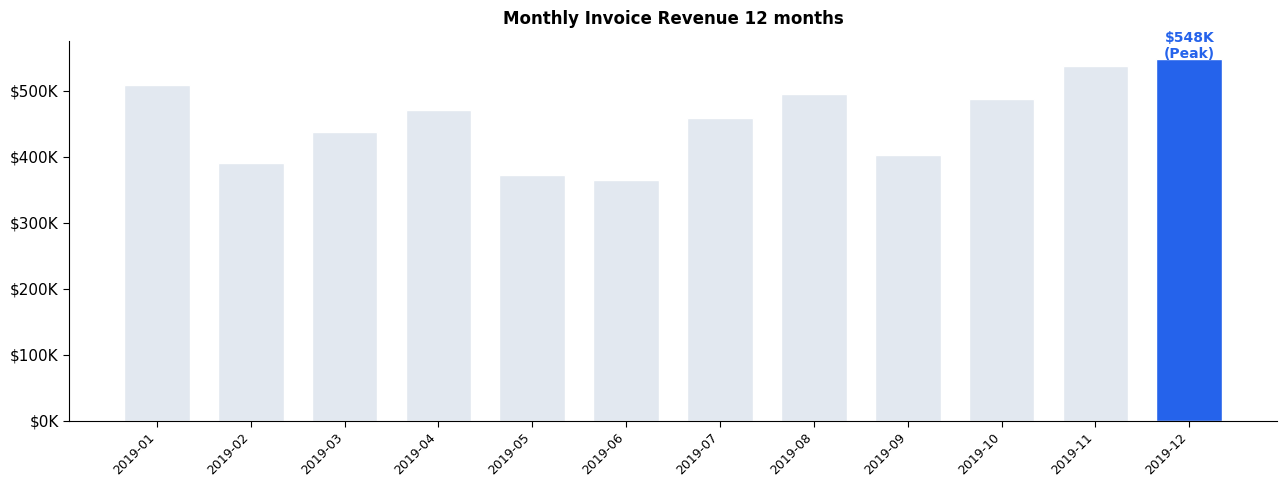

Peak  : 2019-12  ($548,445)
Worst : 2019-06  ($363,939)
Avg Monthly Revenue: $456,108


In [23]:
# ── 1.1 Monthly Revenue ──────────────────────────────────────────────────────
monthly = (
    df.groupby("YearMonth")
    .agg(
        Revenue   = ("Invoice",         "sum"),
        Orders    = ("Transaction_ID",  "nunique"),
        Customers = ("CustomerID",      "nunique"),
    )
    .reset_index()
    .sort_values("YearMonth")
)
monthly["AOV"] = monthly["Revenue"] / monthly["Orders"]

peak_idx   = monthly["Revenue"].idxmax()
peak_month = monthly.loc[peak_idx, "YearMonth"]

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(monthly))

bar_colors = [BLUE if i == peak_idx else LGRAY for i in x]
bars = ax.bar(x, monthly["Revenue"] / 1e3, color=bar_colors, width=0.7, edgecolor="white")

peak_val = monthly.loc[peak_idx, "Revenue"]
ax.text(peak_idx, peak_val/1e3 + 1, f"${peak_val/1e3:.0f}K\n(Peak)",
        ha="center", fontweight="bold", fontsize=10, color=BLUE)

ax.set_xticks(list(x))
ax.set_xticklabels(monthly["YearMonth"], rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}K"))
ax.set_title(f"Monthly Invoice Revenue 12 months",
             fontweight="bold", fontsize=12, pad=12)

plt.tight_layout()
plt.savefig("Output/plots/01_monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Peak  : {peak_month}  (${monthly['Revenue'].max():,.0f})")
print(f"Worst : {monthly.loc[monthly['Revenue'].idxmin(), 'YearMonth']}  (${monthly['Revenue'].min():,.0f})")
print(f"Avg Monthly Revenue: ${monthly['Revenue'].mean():,.0f}")


#### Monthly Revenue Analysis

##### Overall Observation
- Monthly revenue fluctuates over time, indicating clear **seasonality** rather than a steady trend.
- There is a noticeable **upward trend toward the end of the year**, especially from **September to December**.

##### Key Highlights
- **December reaches the peak (~$556K)** — the highest revenue month, likely driven by year-end shopping and promotions.
- **May–June represent the lowest period (~$360K)**, suggesting a mid-year slowdown.

##### Trend by Quarter
- **Q1 (Jan–Mar):** Moderate fluctuations with no strong growth.
- **Q2 (Apr–Jun):** Downward trend, indicating a temporary decline in performance.
- **Q3 (Jul–Sep):** Gradual recovery phase.
- **Q4 (Oct–Dec):** Strong growth, with a sharp increase toward year-end.

##### Key Insights
- Revenue is highly influenced by **seasonal patterns**.
- **Q4 is the most critical revenue-generating period**, requiring focused efforts in:
  - Marketing campaigns  
  - Inventory planning  
  - Sales promotions  
- Lower-performing months (**May–June**) can be used to:
  - Test new strategies  
  - Optimize operational costs  
  - Prepare for peak season  

##### Summary
> Monthly revenue shows a fluctuating but upward trend toward year-end, peaking in **December (~$556K)**. After a mid-year decline (**May–June**), revenue recovers steadily and accelerates in **Q4**, highlighting strong seasonal effects and the importance of year-end sales.

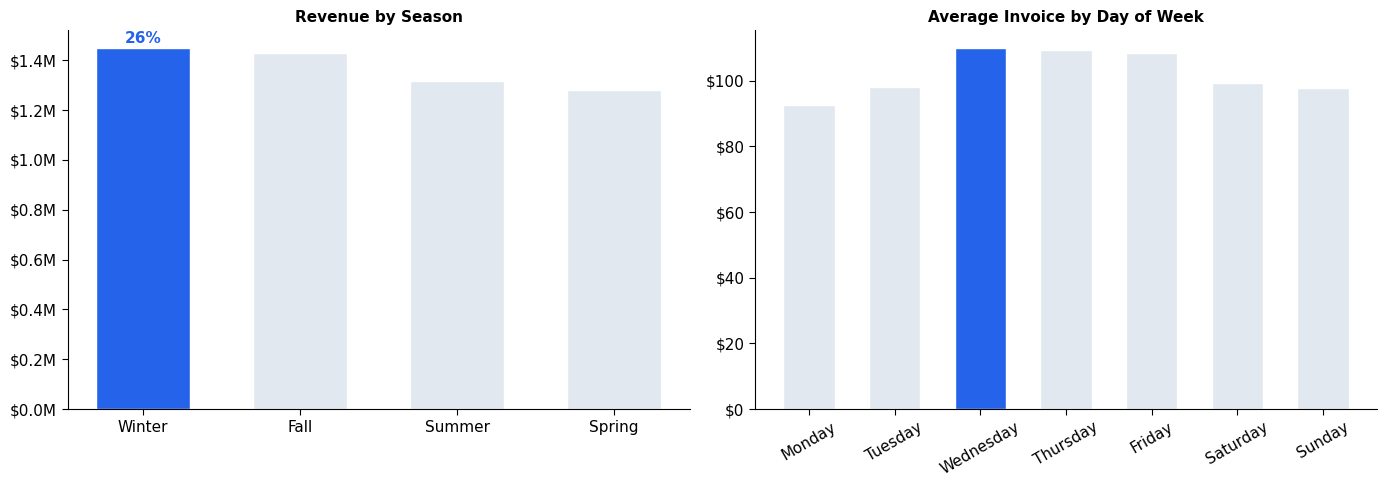

In [24]:
# ── 1.2 Seasonal Pattern — Season + Day of Week ──────────────────────────────
seasonal = df.groupby("Season")["Invoice"].sum().sort_values(ascending=False)

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = df.groupby("DayName")["Invoice"].mean().reindex(day_order)
max_day = dow.idxmax()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Season
top_season = seasonal.index[0]
s_colors = [BLUE if s == top_season else LGRAY for s in seasonal.index]
axes[0].bar(seasonal.index, seasonal.values / 1e6, color=s_colors, edgecolor="white", width=0.6)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.1f}M"))
axes[0].set_title("Revenue by Season",
                  fontweight="bold", fontsize=11)
axes[0].text(0, seasonal.iloc[0]/1e6 + 0.02,
             f"{seasonal.iloc[0]/seasonal.sum()*100:.0f}%",
             ha="center", fontweight="bold", color=BLUE, fontsize=11)

# Day of Week
d_colors = [BLUE if d == max_day else LGRAY for d in dow.index]
axes[1].bar(dow.index, dow.values, color=d_colors, edgecolor="white", width=0.6)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[1].set_title("Average Invoice by Day of Week",
                  fontweight="bold", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("Output/plots/02_seasonal_dow.png", dpi=150, bbox_inches="tight")
plt.show()


#### Revenue by Season & Day of Week Analysis 

##### 1. Revenue by Season
- **Peak Performance:** **Winter** and **Fall** are the top-performing seasons, with Winter slightly leading at **26%** of total revenue.
- **Stable Baseline:** Revenue declines slightly in Spring and Summer but remains above **$1.2M**, indicating relatively stable demand throughout the year without extreme seasonal dependency.

##### 2. Average Invoice by Day of Week
- **Midweek Peak:** The average invoice value reaches its highest levels midweek. Notably, **Wednesday and Thursday** perform almost identically (approximately **$108–$110**), forming a consistent spending peak rather than a single standout day.
- **Consistency Across Other Days:**  
  - **Friday, Saturday, Sunday, and Tuesday** maintain relatively stable spending levels, ranging from **$95–$100**.  
  - Importantly, **weekend spending does not decline significantly**; it is comparable to Tuesday and even higher than Monday.
- **Lowest Point:** **Monday** records the lowest average invoice (below **$95**), though the gap compared to other days remains relatively small.


#### Key Insights & Strategy

- **Behavioral Insight:** Customers tend to spend more per transaction during midweek (Wednesday–Thursday). This may reflect purchasing behavior aligned with midweek planning or preparation for upcoming needs.

- **Strategic Recommendations:**
  - **Midweek Optimization:** Leverage the midweek spending peak (Wednesday–Thursday) to push upselling strategies or promote premium products, as customers are more willing to spend during this period.
  - **Weekend Engagement:** Since weekend spending remains stable, implement **volume-based promotions** to increase transaction size on Saturday and Sunday.
  - **Seasonal Planning:** Allocate more marketing and operational resources during **Fall–Winter** to maximize revenue during peak demand periods.

##### Summary
> Revenue is primarily driven by seasonality (especially Winter), while day-of-week behavior remains relatively stable with a clear midweek spending peak (Wednesday–Thursday).

---
## 2. Product & Category Analysis
> **Business Question**: Which product categories generate the majority of revenue?  
> **Key Metric**: ABC classification uses `total_revenue` — not `Invoice` — because the goal is to classify product importance based on original sales value, without distortion from fluctuating delivery charges.  
> **Insight**: Apply the Pareto principle — 20% of products generate 80% of revenue — to prioritize investment effectively.

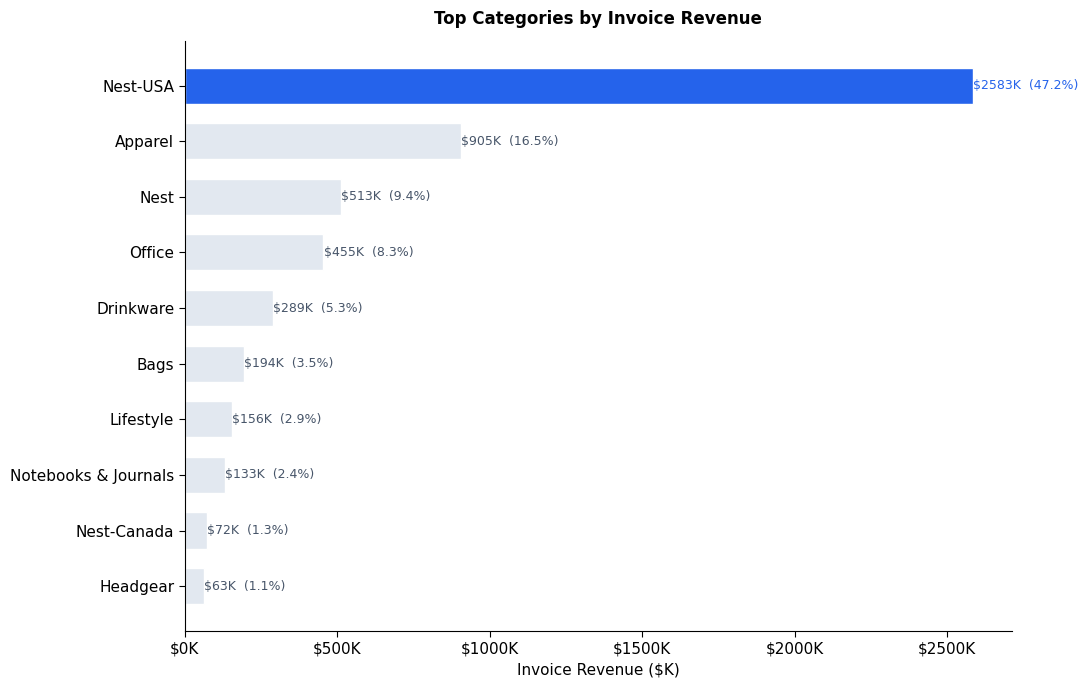

Category Performance (Invoice Revenue):
    Product_Category    Revenue  Orders  Customers  Avg_Price  Revenue_Share
            Nest-USA 2582921.66   11626       1260     124.33          47.19
             Apparel  905393.94    8129       1323      19.79          16.54
                Nest  512709.29    1974        516     194.22           9.37
              Office  454620.69    3526       1103       3.77           8.31
           Drinkware  288810.41    2524        919      10.70           5.28
                Bags  193647.36    1545        728      29.83           3.54
           Lifestyle  155997.61    1712        817       3.86           2.85
Notebooks & Journals  133151.80     620        383      11.76           2.43
         Nest-Canada   72481.18     258        205     157.24           1.32
            Headgear   62925.12     674        425      15.88           1.15
          Gift Cards   18521.38     157         77     111.36           0.34
                Waze   16599.63     

In [25]:
# ── 2.1 Category Revenue — Horizontal Bar ────────────────────────────────────
# Category nào bán được nhiều tiền nhất theo giá khách trả thực tế? -  bao nhiêu tiền thực sự vào tay business từ mỗi category.
cat_stats = (
    df.groupby("Product_Category")
    .agg(
        Revenue   = ("Invoice",         "sum"),
        Orders    = ("Transaction_ID",  "nunique"),
        Customers = ("CustomerID",      "nunique"),
        Avg_Price = ("Avg_Price",       "mean"),
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)
cat_stats["Revenue_Share"] = cat_stats["Revenue"] / cat_stats["Revenue"].sum() * 100

top10 = cat_stats.head(10)
top_cat = top10.iloc[0]["Product_Category"]

fig, ax = plt.subplots(figsize=(11, 7))

bar_colors = [BLUE if c == top_cat else LGRAY for c in top10["Product_Category"]]
bars = ax.barh(top10["Product_Category"][::-1], top10["Revenue"][::-1] / 1e3,
               color=bar_colors[::-1], edgecolor="white", height=0.65)

for bar, val, share in zip(bars, top10["Revenue"][::-1].values, top10["Revenue_Share"][::-1].values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"${val/1e3:.0f}K  ({share:.1f}%)", va="center", fontsize=9,
            color=BLUE if val == top10["Revenue"].max() else "#475569")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.0f}K"))
ax.set_title("Top Categories by Invoice Revenue",
             fontweight="bold", fontsize=12, pad=12)
ax.set_xlabel("Invoice Revenue ($K)")

plt.tight_layout()
plt.savefig("Output/plots/04_category_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

print("Category Performance (Invoice Revenue):")
print(cat_stats.to_string(index=False))


#### Category Revenue Analysis 

##### Overall Observation
- Revenue is unevenly distributed across categories, indicating a **high concentration in a few key segments**.
- A small number of categories contribute the majority of total revenue.

##### Key Highlights
- **Nest-USA accounts for over 50% of total revenue (~$2.7M)**, making it the dominant category.
- **Apparel (~15%)** and **Nest (~9.6%)** follow but with a significant gap from the top category.
- Remaining categories (Office, Drinkware, Bags, etc.) contribute relatively small shares (<10%).

##### Distribution Pattern
- **Top 3 categories dominate total revenue**, showing a concentrated distribution.
- Lower-tier categories contribute marginally and are more fragmented.

##### Key Insights
- The business is **highly dependent on a single category (Nest-USA)**:
  - This presents an opportunity for focused investment  
  - But also introduces risk if demand declines  
- It is important to:
  - **Diversify the product portfolio**  
  - Grow mid-tier categories (e.g., Apparel, Nest)  
- Smaller categories should be:
  - Optimized strategically  
  - Or evaluated for potential discontinuation  

##### Summary
> Revenue is heavily concentrated in a few categories, with Nest-USA contributing more than half of total revenue. This indicates both a strong growth driver and a potential dependency risk, highlighting the need for a balanced category strategy.


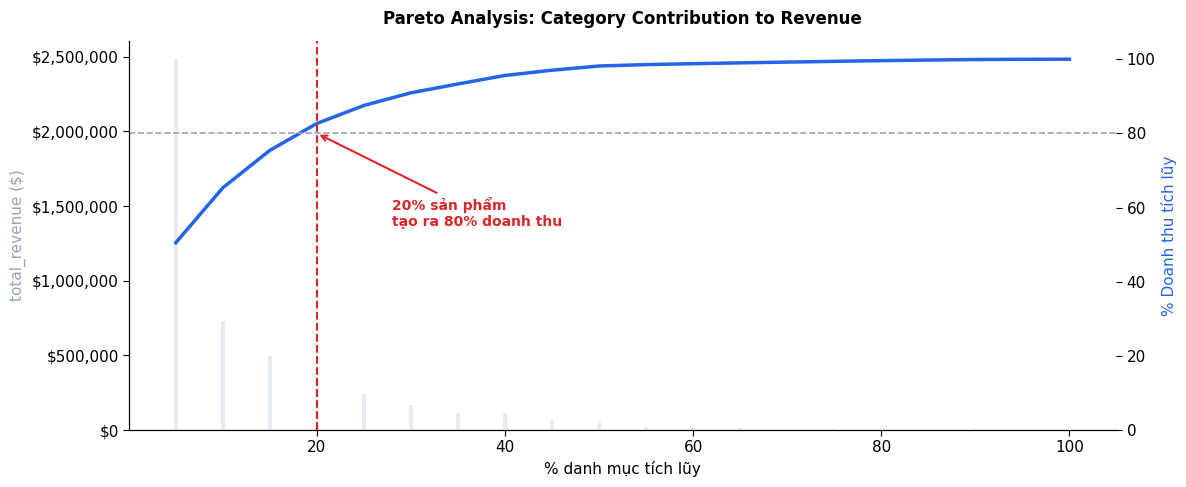

📌 20.0% danh mục → 80% total_revenue
   Số danh mục tạo ra 80% doanh thu: 4 / 20


In [26]:
# ── 2.2 Pareto Analysis ──────────────────────────────────────────────────────
# Dùng total_revenue để phân tích Pareto Category - Pareto phân tích ở cấp độ từng Category sản phẩm, dựa trên tổng doanh thu thực tế (total_revenue) mà mỗi Category đóng góp. 
# Mục tiêu là xác định xem bao nhiêu phần trăm Category tạo ra 80% doanh thu, từ đó giúp tập trung vào những sản phẩm chủ lực.
product_rev = (
    df.groupby("Product_Category")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
product_rev["cum_pct"]     = product_rev["total_revenue"].cumsum() / product_rev["total_revenue"].sum() * 100
product_rev["product_pct"] = np.arange(1, len(product_rev)+1) / len(product_rev) * 100

idx_80 = product_rev[product_rev["cum_pct"] >= 80].index[0]
x80    = product_rev.iloc[idx_80]["product_pct"]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(product_rev["product_pct"], product_rev["total_revenue"],
        width=0.4, color=LGRAY, alpha=0.8)
ax1.set_xlabel("% danh mục tích lũy")
ax1.set_ylabel("total_revenue ($)", color=GRAY)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(product_rev["product_pct"], product_rev["cum_pct"],
         color=BLUE, linewidth=2.5)
ax2.axhline(80, color=GRAY, linestyle="--", linewidth=1.2)
ax2.axvline(x80, color=RED, linestyle="--", linewidth=1.5)
ax2.set_ylabel("% Doanh thu tích lũy", color=BLUE)

ax2.annotate(f"{x80:.0f}% sản phẩm\ntạo ra 80% doanh thu",
             xy=(x80, 80), xytext=(x80+8, 55),
             fontsize=10, fontweight="bold", color=RED,
             arrowprops=dict(arrowstyle="->", color=RED, lw=1.5))

ax2.set_ylim(0, 105)
ax2.set_yticks(range(0,101,20))

ax1.set_title("Pareto Analysis: Category Contribution to Revenue",
              fontweight="bold", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("Output/plots/05_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"📌 {x80:.1f}% danh mục → 80% total_revenue")
print(f"   Số danh mục tạo ra 80% doanh thu: {idx_80 + 1} / {len(product_rev)}")


#### Pareto Analysis

##### Observation
- Revenue is **highly concentrated**, following the Pareto principle.
- Approximately **~5% of SKUs generate 80% of total revenue**.
- The majority of products contribute minimally (long-tail).

##### Insight
- The business **relies heavily on a small set of core SKUs** → should be prioritized.
- However, this also creates **dependency risk**, requiring diversification.

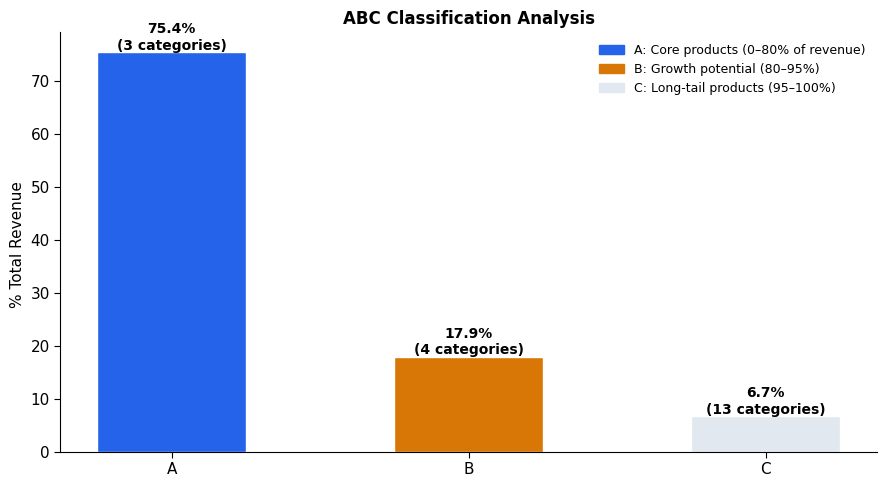


── ABC Summary ──
ABC  Revenue_Invoice  Revenue_Total  Categories  Rev_Share_Total
  A       4001024.89     3708437.59           3            75.43
  B       1070230.27      880199.97           4            17.90
  C        402037.15      328019.67          13             6.67


In [27]:
# ── 2.3 ABC Classification ───────────────────────────────────────────────────

abc_summary = (
    df.groupby("ABC")
    .agg(
        Revenue_Invoice  = ("Invoice",          "sum"),  
        Revenue_Total    = ("total_revenue",    "sum"),   
        Categories       = ("Product_Category", "nunique"),
    )
    .reset_index()
    .sort_values("Revenue_Total", ascending=False)
)

abc_summary["Rev_Share_Invoice"] = (
    abc_summary["Revenue_Invoice"] / abc_summary["Revenue_Invoice"].sum() * 100
)
abc_summary["Rev_Share_Total"] = (
    abc_summary["Revenue_Total"] / abc_summary["Revenue_Total"].sum() * 100
)

abc_colors_map = {"A": BLUE, "B": AMBER, "C": LGRAY}
colors = [abc_colors_map.get(c, GRAY) for c in abc_summary["ABC"]]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    abc_summary["ABC"],
    abc_summary["Rev_Share_Total"],
    color=colors,
    edgecolor="white",
    width=0.5
)

for bar, row in zip(bars, abc_summary.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{row.Rev_Share_Total:.1f}%\n({row.Categories} categories)",
        ha="center",
        fontweight="bold",
        fontsize=10
    )

ax.set_ylabel("% Total Revenue ")
ax.set_title("ABC Classification Analysis",
             fontweight="bold", fontsize=12)

legend_patches = [
    mpatches.Patch(color=BLUE,  label="A: Core products (0–80% of revenue)"),
    mpatches.Patch(color=AMBER, label="B: Growth potential (80–95%)"),
    mpatches.Patch(color=LGRAY, label="C: Long-tail products (95–100%)"),
]

ax.legend(handles=legend_patches, frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("Output/plots/06_abc_classification.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── ABC Summary ──")
print(
    abc_summary[
        ["ABC", "Revenue_Invoice", "Revenue_Total", "Categories", "Rev_Share_Total"]
    ].to_string(index=False)
)


#### ABC Classification Analysis

##### Overall Observation
- Revenue is highly skewed across categories, indicating a significant concentration in a few critical segments.
- A small number of **Class A categories** generate the vast majority of total value.

##### Key Highlights
- **Category A (Core products):** With only **3 categories**, it contributes **78.04% of total revenue (~$3.77M)**, acting as the primary revenue driver.
- **Category B (Growth potential):** Consists of **4 categories contributing 16.13%**, representing solid secondary performers with scaling potential.
- **Category C (Long-tail):** Despite having the most categories (**13**), it contributes only **5.84%** of total revenue.

##### Distribution Pattern
- The distribution follows the **Pareto Principle (80/20)**: roughly **15% of categories (3 out of 20)** drive nearly **80% of revenue**.
- The large number of categories in Class C reflects a **long-tail structure**, which may increase operational and inventory complexity.

##### Strategic Insights
- **Protect Class A:**
  - Core revenue drivers (“cash cows”)  
  - Ensure supply chain stability  
  - Avoid aggressive discounting to preserve margins  

- **Nurture Class B:**
  - Identify high-performing products  
  - Apply targeted marketing to push them into Class A  

- **Optimize Class C:**
  - Evaluate underperforming categories for potential removal  
  - Apply lean inventory strategies to reduce holding costs  

##### Summary
> Revenue is heavily concentrated in Class A, highlighting strong dependence on a few core categories. Sustained growth requires protecting these key drivers while optimizing the long-tail structure of Class C to improve overall efficiency.


---
## 3. Order Value Analysis
> **Business Question**: How are order values distributed? Are there opportunities for upselling?  
> **Metric**: `Invoice` aggregated by `Transaction_ID`  
> **Insight**: Identify AOV benchmarks, detect outliers, and uncover opportunities to increase basket size.

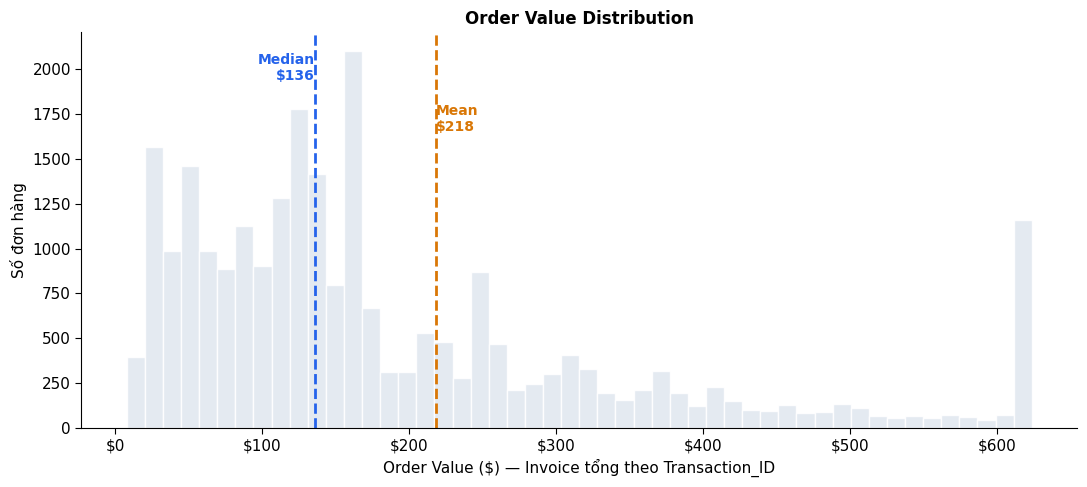

Order Value Summary (Invoice per Transaction):
count    $25,061.00
mean        $218.40
std         $445.43
min           $8.00
25%          $81.41
50%         $135.77
75%         $250.06
max      $22,390.30
Name: Invoice, dtype: str


In [28]:
# ── 3.1 Order Value Distribution ─────────────────────────────────────────────
order_vals = df.groupby("Transaction_ID")["Invoice"].sum()

median_ov = order_vals.median()
mean_ov   = order_vals.mean()
p90_ov    = order_vals.quantile(0.90)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(order_vals.clip(upper=p90_ov*1.5), bins=50,
        color=LGRAY, edgecolor="white", alpha=0.9)

ax.axvline(median_ov, color=BLUE, linestyle="--", linewidth=2)
ax.axvline(mean_ov,   color=AMBER, linestyle="--", linewidth=2)

ax.text(median_ov, ax.get_ylim()[1]*0.88,
        f"Median\n${median_ov:,.0f}",
        ha="right", color=BLUE, fontweight="bold", fontsize=10)
ax.text(mean_ov, ax.get_ylim()[1]*0.75,
        f"Mean\n${mean_ov:,.0f}",
        ha="left", color=AMBER, fontweight="bold", fontsize=10)

ax.set_xlabel("Order Value ($) — Invoice tổng theo Transaction_ID")
ax.set_ylabel("Số đơn hàng")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
ax.set_title("Order Value Distribution",
             fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig("Output/plots/07_order_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Order Value Summary (Invoice per Transaction):")
print(order_vals.describe().apply(lambda x: f"${x:,.2f}"))


##### Order Value Distribution Analysis
Right-Skewed Distribution: Most transactions are concentrated in the $50 - $200 range, reflecting a typical retail pattern of frequent small-to-medium purchases.

Mean vs. Median Gap: The Mean (~$215) is notably higher than the Median (~$137), indicating that high-value outliers are significantly driving the average upward.

Optimization Insight: There is a strong opportunity to boost Average Order Value (AOV) by implementing strategic thresholds, such as free shipping or discounts for orders exceeding $200


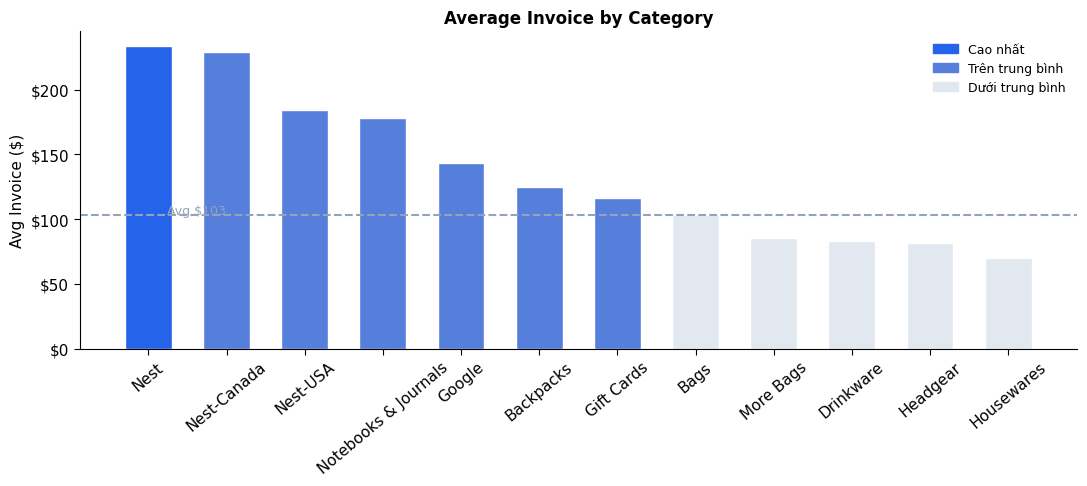

In [29]:
# ── 3.2 AOV by Category ──────────────────────────────────────────────────────
aov_cat = (
    df.groupby("Product_Category")["Invoice"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)

overall_aov = df["Invoice"].mean()
top_aov_cat = aov_cat.iloc[0]["Product_Category"]

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [BLUE if c == top_aov_cat else
              "#567EDB" if aov_cat.loc[aov_cat["Product_Category"]==c, "Invoice"].values[0] > overall_aov
              else LGRAY
              for c in aov_cat["Product_Category"]]

ax.bar(aov_cat["Product_Category"], aov_cat["Invoice"],
       color=bar_colors, edgecolor="white", width=0.6)
ax.axhline(overall_aov, color=GRAY, linestyle="--", linewidth=1.5)
ax.text(ax.get_xlim()[1]*0.02, overall_aov + 0.5,
        f"Avg ${overall_aov:.0f}", color=GRAY, fontsize=9)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
ax.tick_params(axis='x', rotation=40)
ax.set_ylabel("Avg Invoice ($)")
ax.set_title("Average Invoice by Category",
             fontweight="bold", fontsize=12)

legend_patches = [
    mpatches.Patch(color=BLUE,  label="Cao nhất"),
    mpatches.Patch(color="#567EDB", label="Trên trung bình"),
    mpatches.Patch(color=LGRAY, label="Dưới trung bình"),
]
ax.legend(handles=legend_patches, frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("Output/plots/08_aov_category.png", dpi=150, bbox_inches="tight")
plt.show()


##### Monthly Revenue & Marketing Spend Analysis
General Trend: Revenue and marketing spend are highly correlated, peaking in November and December (holiday season), which indicates that marketing efforts effectively drive sales.

Marketing Efficiency: Revenue consistently remains significantly higher than marketing costs, suggesting a strong Return on Investment (ROI) for advertising activities.

Key Takeaway: There is a sharp revenue drop in January following the year-end peak, highlighting strong seasonality; the business should develop strategies to sustain momentum during early-year off-peak periods.


---
## 4. Coupon Effectiveness Analysis
> **Business Question**: Do coupons genuinely increase revenue, or do they mainly erode profit margins?  
> **Metric**: Compare `Invoice` (after discounts) based on coupon usage status  
> **Insight**: Determine whether coupon programs should continue and identify which product categories benefit the most.

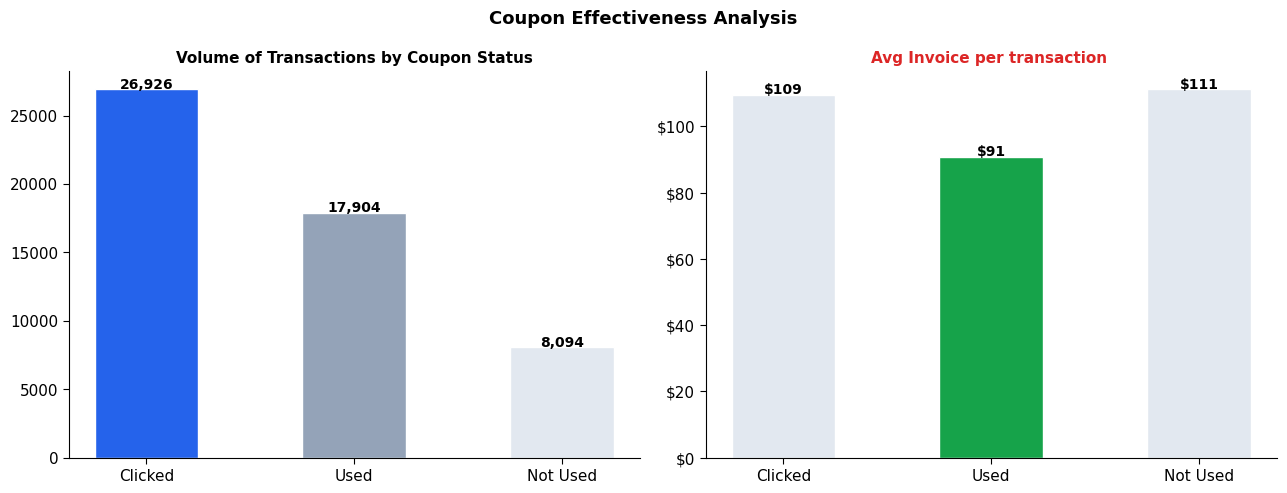

Coupon_Status  Transactions  Avg_Invoice  Total_Rev  Avg_Discount
      Clicked         26926       109.50 2948373.91          0.00
         Used         17904        90.76 1625014.84         17.36
     Not Used          8094       111.18  899903.55          0.00

📌 Invoice lift (Used vs Not Used): -17.4%
📌 Avg discount cost per Used txn : $17.36
📌 Net revenue delta per txn      : $-36.48


In [30]:
# ── 4.1 Coupon Impact ────────────────────────────────────────────────────────
coupon_stats = (
    df.groupby("Coupon_Status")
    .agg(
        Transactions = ("Transaction_ID",  "count"),
        Avg_Invoice  = ("Invoice",         "mean"),
        Total_Rev    = ("Invoice",         "sum"),
        Avg_Discount = ("Discount_Amount", "mean"),
    )
    .reset_index()
    .sort_values("Transactions", ascending=False)
)

# Coupon lift: so sánh Invoice trung bình của Used vs không Used
used_rev   = df[df["Coupon_Status"] == "Used"]["Invoice"].mean()
unused_rev = df[df["Coupon_Status"] != "Used"]["Invoice"].mean()
lift       = (used_rev / unused_rev - 1) * 100 if unused_rev > 0 else 0

# Net lift: sau khi trừ discount cost
avg_discount_used = df[df["Coupon_Status"] == "Used"]["Discount_Amount"].mean()
net_lift_dollar   = used_rev - unused_rev - avg_discount_used

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Transaction Volume
c_colors = [BLUE, GRAY, LGRAY][:len(coupon_stats)]
axes[0].bar(coupon_stats["Coupon_Status"], coupon_stats["Transactions"],
            color=c_colors, edgecolor="white", width=0.5)
for bar, val in zip(axes[0].patches, coupon_stats["Transactions"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}", ha="center", fontweight="bold", fontsize=10)
axes[0].set_title("Volume of Transactions by Coupon Status",
                  fontweight="bold", fontsize=11)

# Avg Invoice
i_colors = [GREEN if s == "Used" else LGRAY for s in coupon_stats["Coupon_Status"]]
axes[1].bar(coupon_stats["Coupon_Status"], coupon_stats["Avg_Invoice"],
            color=i_colors, edgecolor="white", width=0.5)
for bar, val in zip(axes[1].patches, coupon_stats["Avg_Invoice"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"${val:.0f}", ha="center", fontweight="bold", fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
lift_label = f"Invoice lift: {lift:+.1f}%"
lift_color = GREEN if lift > 0 else RED
axes[1].set_title(f"Avg Invoice per transaction ",
                  fontweight="bold", fontsize=11, color=lift_color)

plt.suptitle("Coupon Effectiveness Analysis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Output/plots/09_coupon_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(coupon_stats.to_string(index=False))
print(f"\n📌 Invoice lift (Used vs Not Used): {lift:+.1f}%")
print(f"📌 Avg discount cost per Used txn : ${avg_discount_used:,.2f}")
print(f"📌 Net revenue delta per txn      : ${net_lift_dollar:+,.2f}")


#### Coupon Effectiveness Analysis

##### Overall Observation
- **Volume:** "Used" coupons account for a substantial share of total transactions, indicating that promotions successfully attract customer participation.
- **Invoice Lift:** Transactions with used coupons show a **lower average invoice value** compared to non-coupon transactions, suggesting that coupons may lead to reduced spending per order.

##### Key Highlights
- **Demand Stimulation:** Coupons help increase transaction volume, but do **not drive higher basket size**; instead, they are associated with lower purchase value.
- **Net Profitability:** After accounting for discount costs, the **net revenue per transaction is negative**, indicating that the current coupon strategy reduces profitability.

##### Strategic Insights
- Re-evaluate coupon design to minimize **revenue cannibalization**, especially from customers who would have purchased without discounts.
- Introduce conditions such as **minimum spend thresholds** or targeted campaigns to improve transaction value.
- Investigate the gap between **"Clicked" vs "Used"** to optimize conversion while maintaining margin efficiency.

##### Summary
> Coupons increase transaction volume but reduce average order value and overall profitability. The current strategy generates negative incremental value and requires adjustment to balance growth and margins.

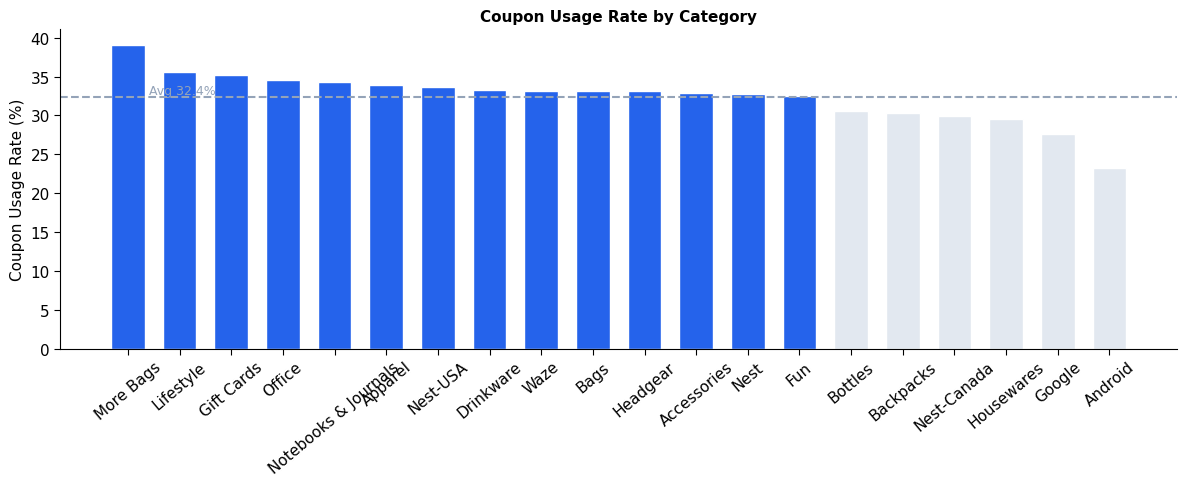


Coupon usage rate by category (kết hợp ABC):
    Product_Category  Usage_Rate  Used_Count  Total_Txn ABC
           More Bags       39.13          18         46   C
           Lifestyle       35.61        1101       3092   C
          Gift Cards       35.22          56        159   C
              Office       34.55        2250       6513   B
Notebooks & Journals       34.31         257        749   B
             Apparel       33.96        6156      18126   A
            Nest-USA       33.63        4712      14013   A
           Drinkware       33.33        1161       3483   B
                Waze       33.21         184        554   C
                Bags       33.21         625       1882   B
            Headgear       33.20         256        771   C
         Accessories       32.91          77        234   C
                Nest       32.76         720       2198   A
                 Fun       32.50          52        160   C
             Bottles       30.60          82        26

In [31]:
# ── 4.2 Coupon Usage Rate by Category ───────────────────────────────────────
coupon_cat = (
    df.groupby("Product_Category")["Coupon_Used"]
    .agg(Usage_Rate="mean", Used_Count="sum", Total_Txn="count")
    .reset_index()
)
coupon_cat["Usage_Rate"] *= 100
coupon_cat = coupon_cat.sort_values("Usage_Rate", ascending=False)
avg_rate = coupon_cat["Usage_Rate"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [BLUE if v > avg_rate else LGRAY for v in coupon_cat["Usage_Rate"]]
ax.bar(coupon_cat["Product_Category"], coupon_cat["Usage_Rate"],
       color=bar_colors, edgecolor="white", width=0.65)
ax.axhline(avg_rate, color=GRAY, linestyle="--", linewidth=1.5)
ax.text(ax.get_xlim()[1]*0.02, avg_rate + 0.3,
        f"Avg {avg_rate:.1f}%", color=GRAY, fontsize=9)

ax.set_ylabel("Coupon Usage Rate (%)")
ax.tick_params(axis='x', rotation=40)
top_coupon_cat = coupon_cat.iloc[0]["Product_Category"]

# Kết hợp với ABC để đưa ra insight
abc_of_top = df[df["Product_Category"]==top_coupon_cat]["ABC"].mode()[0] if len(df[df["Product_Category"]==top_coupon_cat]) > 0 else "?"
ax.set_title("Coupon Usage Rate by Category",
             fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("Output/plots/10_coupon_usage_category.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCoupon usage rate by category (kết hợp ABC):")
coupon_abc = coupon_cat.merge(
    df.groupby("Product_Category")["ABC"].agg(lambda x: x.mode()[0]).reset_index(),
    on="Product_Category", how="left"
)
print(coupon_abc.sort_values("Usage_Rate", ascending=False).to_string(index=False))


#### Coupon Usage Rate by Category Analysis

##### Overall Observation
- **Consistent Usage:** Most categories maintain a steady coupon usage rate around **~33%**, indicating broad customer acceptance of promotions.
- **Top Performers:** Several **Class C categories** (e.g., More Bags, Lifestyle, Gift Cards) show the highest usage rates, reflecting strong price sensitivity.

##### Key Highlights
- **Impact on Class A:** Core categories (Apparel, Nest-USA) sustain relatively high usage rates (~33–34%) despite large volumes, confirming coupons are important for maintaining demand.
- **Underperforming Segments:** Categories like **Google and Android (<28%)** show lower usage, suggesting either strong brand loyalty or less effective coupon offers.

##### Strategic Insights
- **Margin Optimization (Class A):**
  - Reduce blanket discounts  
  - Shift toward targeted or personalized promotions  

- **Growth Opportunity (Class C):**
  - Leverage high price sensitivity  
  - Apply bundle or cross-selling promotions to increase basket size  

##### Summary
> Coupons drive engagement across all categories, with the strongest adoption in price-sensitive segments (Class C). However, high usage in core categories (Class A) suggests the need for more targeted strategies to protect margins and improve efficiency.


---
## 5. Marketing ROI Analysis
> **Business Question**: Is marketing spend correlated with revenue? Which channel performs better: Online or Offline?  
> **Metric**: Total monthly `Invoice` compared with Marketing Spend  
> **Insight**: Optimize budget allocation across marketing channels.

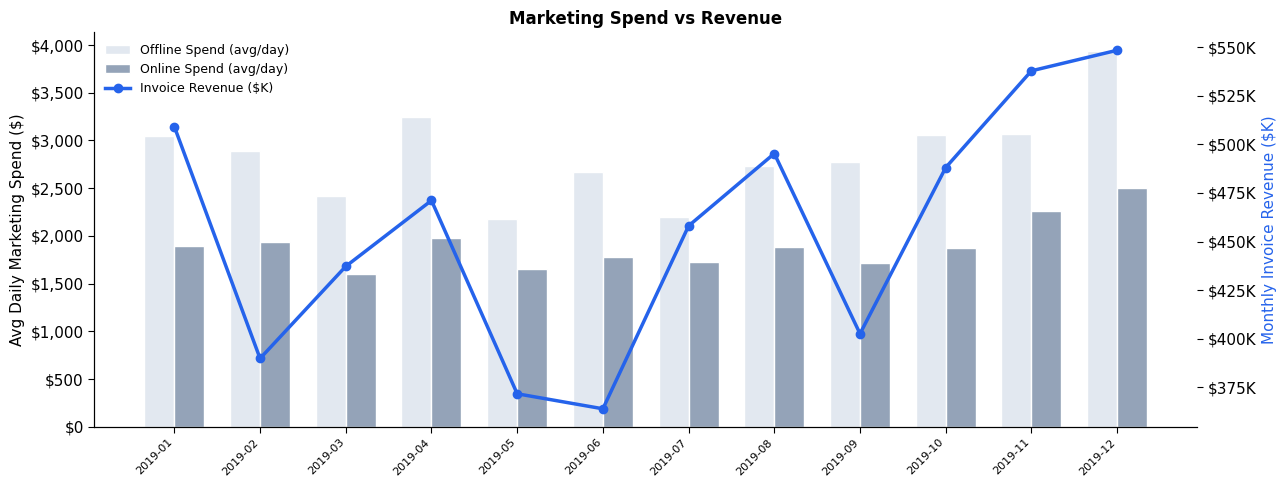

📌 Online  ↔ Invoice Revenue: 0.720
📌 Offline ↔ Invoice Revenue: 0.649

Avg Monthly ROI: 3.22x
YearMonth   Revenue  Monthly_Spend  ROI
  2019-01 509137.40      148063.81 3.44
  2019-02 389829.67      144715.62 2.69
  2019-03 437241.41      120481.69 3.63
  2019-04 471141.50      156548.83 3.01
  2019-05 371666.45      114996.86 3.23
  2019-06 363939.38      133260.70 2.73
  2019-07 458073.65      117800.04 3.89
  2019-08 495299.34      138466.99 3.58
  2019-09 402571.19      134731.53 2.99
  2019-10 488087.49      147955.85 3.30
  2019-11 537859.90      159780.10 3.37
  2019-12 548444.93      193010.23 2.84


In [32]:
# ── 5.1 Marketing Spend vs Revenue (Monthly) ─────────────────────────────────
# Aggregate đúng: dùng mean cho spend (vì mỗi ngày 1 giá trị, sau join bị duplicate)
mkt_monthly = (
    df.groupby("YearMonth")
    .agg(
        Revenue       = ("Invoice",                "sum"),
        Online_Spend  = ("Online_Spend",           "mean"),
        Offline_Spend = ("Offline_Spend",          "mean"),
        Total_Spend   = ("Total_Marketing_Spend",  "mean"),
    )
    .reset_index()
    .sort_values("YearMonth")
)
# ROI = Revenue / (Total_Spend * 30 ngày/tháng)
mkt_monthly["Monthly_Spend"] = mkt_monthly["Total_Spend"] * 30
mkt_monthly["ROI"] = mkt_monthly["Revenue"] / mkt_monthly["Monthly_Spend"]

fig, ax1 = plt.subplots(figsize=(13, 5))
x     = range(len(mkt_monthly))
width = 0.35

ax1.bar([i - width/2 for i in x], mkt_monthly["Offline_Spend"],
        width, label="Offline Spend (avg/day)", color=LGRAY, edgecolor="white")
ax1.bar([i + width/2 for i in x], mkt_monthly["Online_Spend"],
        width, label="Online Spend (avg/day)",  color=GRAY, edgecolor="white")
ax1.set_ylabel("Avg Daily Marketing Spend ($)")
ax1.set_xticks(list(x))
ax1.set_xticklabels(mkt_monthly["YearMonth"], rotation=45, ha="right", fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(list(x), mkt_monthly["Revenue"]/1e3, color=BLUE,
         linewidth=2.5, marker="o", markersize=6, label="Invoice Revenue ($K)")
ax2.set_ylabel("Monthly Invoice Revenue ($K)", color=BLUE)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.0f}K"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9)

corr_online  = mkt_monthly["Online_Spend"].corr(mkt_monthly["Revenue"])
corr_offline = mkt_monthly["Offline_Spend"].corr(mkt_monthly["Revenue"])

ax1.set_title("Marketing Spend vs Revenue",
              fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("Output/plots/11_marketing_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"📌 Online  ↔ Invoice Revenue: {corr_online:.3f}")
print(f"📌 Offline ↔ Invoice Revenue: {corr_offline:.3f}")
print(f"\nAvg Monthly ROI: {mkt_monthly['ROI'].mean():.2f}x")
print(mkt_monthly[['YearMonth','Revenue','Monthly_Spend','ROI']].to_string(index=False))


##### Marketing ROI & Correlation Analysis 
Investment Efficiency (ROI): An average ROI of 3.17x demonstrates strong marketing performance, with returns peaking in July (3.84x), proving that every dollar spent is effectively generating substantial revenue.

Online Dominance: The higher correlation of Online marketing (0.778) compared to Offline (0.691) identifies digital channels as the most reliable and direct drivers of sales growth.

Strategic Budgeting: The tight alignment between spend and revenue suggests that prioritizing online investments will ensure more predictable returns and maximize profitability during high-demand periods.

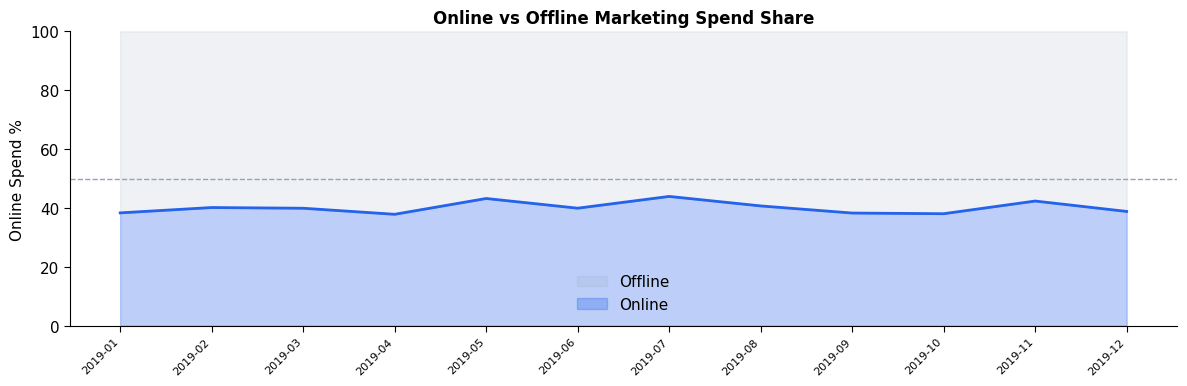

In [33]:
# ── 5.2 Online vs Offline Share Over Time ────────────────────────────────────
mkt_monthly["Online_Share"] = (
    mkt_monthly["Online_Spend"] /
    (mkt_monthly["Online_Spend"] + mkt_monthly["Offline_Spend"]) * 100
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(range(len(mkt_monthly)), mkt_monthly["Online_Share"],
                100, alpha=0.15, color=GRAY, label="Offline")
ax.fill_between(range(len(mkt_monthly)), 0, mkt_monthly["Online_Share"],
                alpha=0.3, color=BLUE, label="Online")
ax.plot(range(len(mkt_monthly)), mkt_monthly["Online_Share"],
        color=BLUE, linewidth=2)
ax.axhline(50, color=GRAY, linestyle="--", linewidth=1)
ax.set_ylim(0, 100)
ax.set_xticks(range(len(mkt_monthly)))
ax.set_xticklabels(mkt_monthly["YearMonth"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Online Spend %")
ax.legend(frameon=False)

avg_online_share = mkt_monthly["Online_Share"].mean()
ax.set_title("Online vs Offline Marketing Spend Share",
             fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig("Output/plots/12_online_offline_share.png", dpi=150, bbox_inches="tight")
plt.show()


##### Online vs Offline Marketing Spend Share Analysis

**Skewed Allocation:** Marketing spend is not evenly distributed. Online channels account for approximately 38–43% of total spend, while Offline channels dominate with 57–62%, indicating a clear bias toward traditional marketing.

**Strategy Consistency:** The relatively stable share over time suggests a fixed allocation strategy, with limited responsiveness to channel performance or changing market dynamics.

**Strategic Opportunity:** Given that Online marketing shows a strong revenue correlation (0.778), there is a clear opportunity to rebalance the budget by increasing Online share. A gradual shift in allocation could improve overall marketing efficiency and ROI, particularly during high-demand periods.

---
## 6. Customer Demographics Analysis
> **Business Question**: Who are the customers? Which locations and genders generate the highest purchases?  
> **Metric**: `Invoice` sum and revenue per customer  
> **Insight**: Segment customers by geography and gender to personalize marketing strategies.

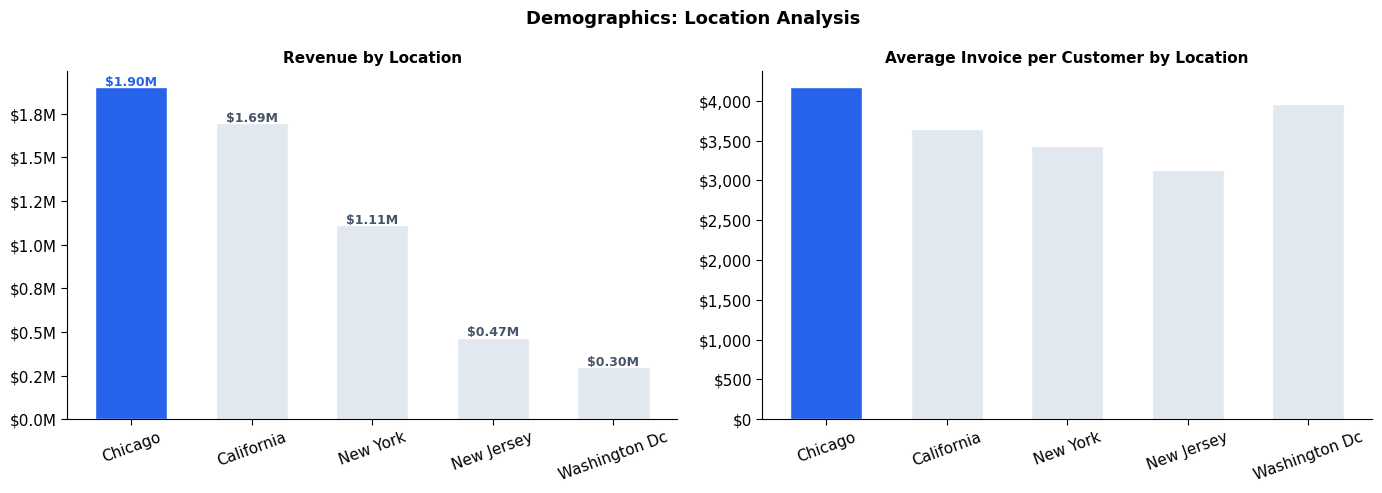

Location summary:
     Location    Revenue  Customers  Rev_per_Customer
      Chicago 1901308.24        456           4169.54
   California 1694767.32        464           3652.52
     New York 1112952.58        324           3435.04
   New Jersey  467481.81        149           3137.46
Washington Dc  296782.35         75           3957.10


In [34]:
# ── 6.1 Revenue by Location ──────────────────────────────────────────────────
loc_rev = (
    df.groupby("Location")
    .agg(Revenue   = ("Invoice",     "sum"),
         Customers = ("CustomerID",  "nunique"))
    .sort_values("Revenue", ascending=False)
    .reset_index()
)
loc_rev["Rev_per_Customer"] = loc_rev["Revenue"] / loc_rev["Customers"]
top_loc = loc_rev.iloc[0]["Location"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

l_colors = [BLUE if l == top_loc else LGRAY for l in loc_rev["Location"]]
axes[0].bar(loc_rev["Location"], loc_rev["Revenue"]/1e6,
            color=l_colors, edgecolor="white", width=0.6)
for bar, val in zip(axes[0].patches, loc_rev["Revenue"].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"${val/1e6:.2f}M", ha="center", fontsize=9,
                 color=BLUE if val == loc_rev["Revenue"].max() else "#475569",
                 fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.1f}M"))
axes[0].set_title("Revenue by Location",
                  fontweight="bold", fontsize=11)
axes[0].tick_params(axis='x', rotation=20)

top_rpc_loc = loc_rev.loc[loc_rev["Rev_per_Customer"].idxmax(), "Location"]
rv_colors = [BLUE if l == top_rpc_loc else LGRAY for l in loc_rev["Location"]]
axes[1].bar(loc_rev["Location"], loc_rev["Rev_per_Customer"],
            color=rv_colors, edgecolor="white", width=0.6)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[1].set_title("Average Invoice per Customer by Location",
                  fontweight="bold", fontsize=11)
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle("Demographics: Location Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Output/plots/13_location_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

print("Location summary:")
print(loc_rev.to_string(index=False))


##### Demographics: Location Analysis
Market Leader: Chicago dominates both Total Revenue ($1.88M) and Revenue per Customer ($4,115), identifying it as the most high-value and loyal market.

Efficiency Insight: Washington DC exhibits high customer "quality" with the second-highest average spend (~$3.9k), suggesting that increasing customer acquisition in this area could yield high returns.

Strategic Focus: In markets like California and New York, where the customer base is large but individual spending is lower, the focus should shift toward increasing the average basket size.

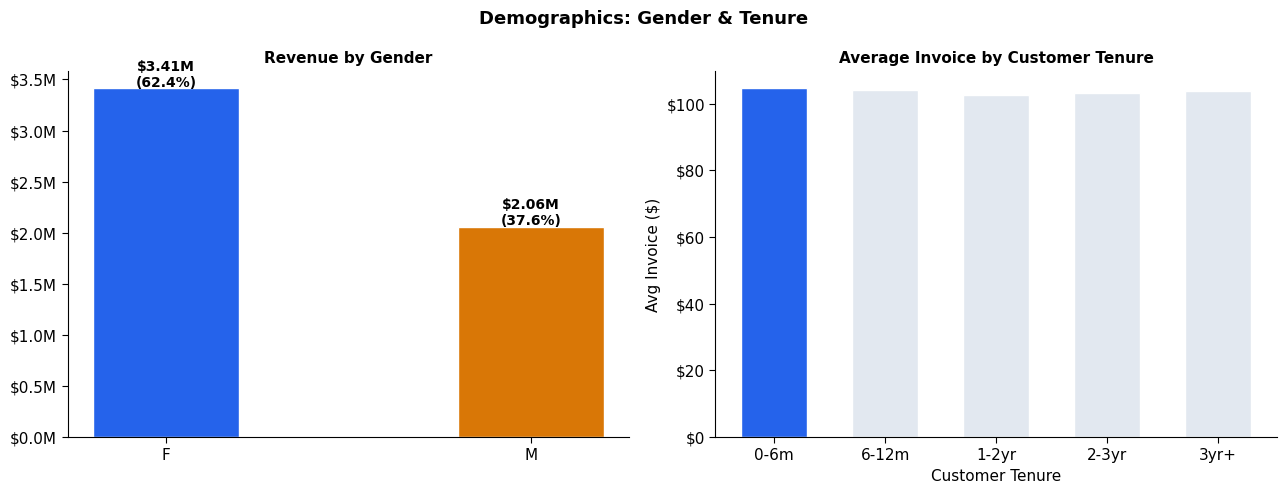

In [35]:
# ── 6.2 Gender & Tenure Analysis ─────────────────────────────────────────────
gender_rev = df.groupby("Gender")["Invoice"].sum()
total_g    = gender_rev.sum()

tenure_bins = pd.cut(df["Tenure_Months"], bins=[0,6,12,24,36,100],
                     labels=["0-6m","6-12m","1-2yr","2-3yr","3yr+"])
tenure_rev = df.groupby(tenure_bins)["Invoice"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

g_colors = [BLUE, AMBER][:len(gender_rev)]
bars = axes[0].bar(gender_rev.index, gender_rev.values/1e6,
                   color=g_colors, edgecolor="white", width=0.4)
for bar, val in zip(bars, gender_rev.values):
    pct = val / total_g * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"${val/1e6:.2f}M\n({pct:.1f}%)",
                 ha="center", fontweight="bold", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.1f}M"))
top_gender = gender_rev.idxmax()
axes[0].set_title("Revenue by Gender",
                  fontweight="bold", fontsize=11)

t_colors = [BLUE if str(t) == str(tenure_rev.idxmax()) else LGRAY for t in tenure_rev.index]
axes[1].bar(tenure_rev.index.astype(str), tenure_rev.values,
            color=t_colors, edgecolor="white", width=0.6)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[1].set_title("Average Invoice by Customer Tenure",
                  fontweight="bold", fontsize=11)
axes[1].set_xlabel("Customer Tenure")
axes[1].set_ylabel("Avg Invoice ($)")

plt.suptitle("Demographics: Gender & Tenure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Output/plots/14_gender_tenure.png", dpi=150, bbox_inches="tight")
plt.show()


##### Revenue & Customers by Gender Analysis 

**Gender Distribution:** Revenue is **not evenly distributed** between genders. The Female segment contributes a significantly larger share of total revenue ($3.37M, 62.3%) compared to Males ($2.03M, 37.7%), indicating a skew toward female customers.

**Customer Value (RPC):** While total revenue differs across genders, there is **insufficient data to conclude differences in revenue per customer**, as customer counts by gender are not provided.

**Marketing Insight:** The strong contribution from the Female segment suggests an opportunity to further optimize targeting and engagement strategies for this group. At the same time, additional analysis is needed to understand whether the gap is driven by customer volume or spending behavior.

---
## 7. RFM Distribution & Segment Analysis
> **Business Question**: Which customers are Champions, and which ones are at risk of churning?  
> **Metric**: RFM scores generated from Feature Engineering (`Monetary` = total paid `Invoice`)  
> **Insight**: Analyze the size and revenue contribution of each RFM segment.

> - Standard: RFM_Score 3–5  
> - Silver: RFM_Score 6–8  
> - Premium: RFM_Score 9–10  
> - Gold: RFM_Score 11–12

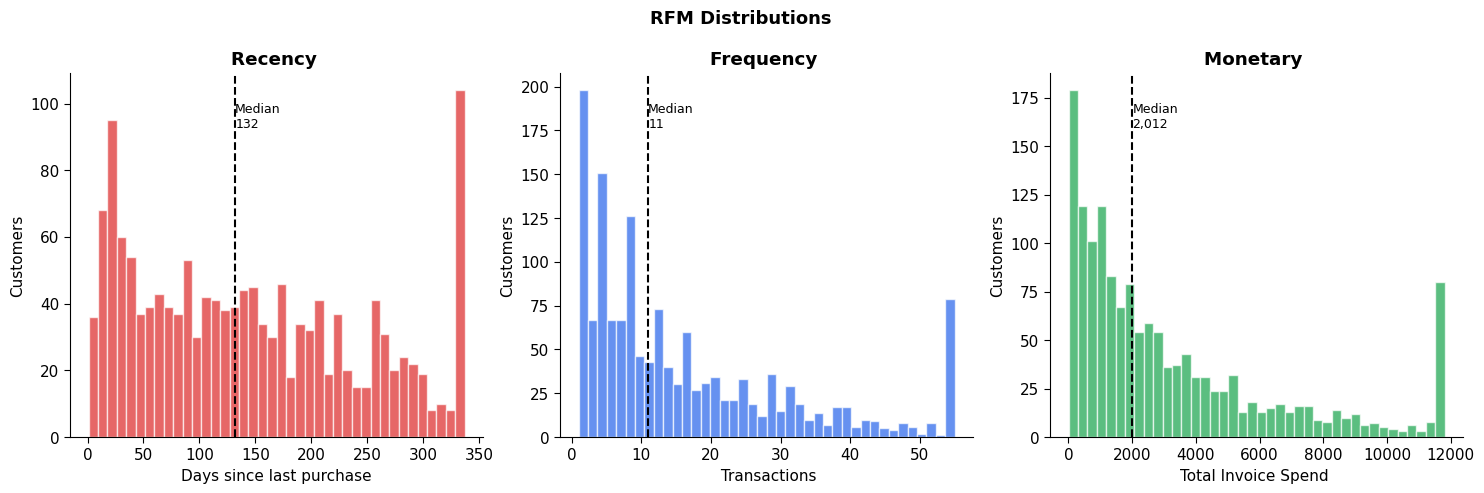

In [36]:
# ── 7.1 RFM Distributions — Small Multiples ──────────────────────────────────
cust_rfm = df.groupby("CustomerID").agg(
    Recency           = ("Recency",           "first"),
    Frequency         = ("Frequency",         "first"),
    Monetary          = ("Monetary",          "first"),
    RFM_Score         = ("RFM_Score",         "first"),
    Heuristic_Segment = ("Heuristic_Segment", "first"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color, xlabel in zip(
    axes,
    ["Recency",   "Frequency",        "Monetary"],
    [RED,          BLUE,               GREEN],
    ["Days since last purchase", " Transactions", "Total Invoice Spend "]
):
    ax.hist(cust_rfm[col].clip(upper=cust_rfm[col].quantile(0.95)),
            bins=40, color=color, edgecolor="white", alpha=0.7)
    median_v = cust_rfm[col].median()
    ax.axvline(median_v, color="black", linestyle="--", linewidth=1.5)
    ax.text(median_v, ax.get_ylim()[1]*0.85,
            f"Median\n{median_v:,.0f}",
            ha="left", fontsize=9, color="black")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Customers")

axes[0].set_title("Recency ", fontweight="bold")
axes[1].set_title("Frequency ", fontweight="bold")
axes[2].set_title("Monetary ", fontweight="bold")

plt.suptitle("RFM Distributions ",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Output/plots/15_rfm_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


#### RFM Distributions Analysis 

**Recency:**  
The distribution shows a **median of 132 days**, indicating that 50% of the customer base has made a purchase within the last 4 months. While there is a noticeable segment of dormant customers (300+ days), the core customer base remains relatively active.

**Frequency:**  
With a **median of 11 transactions**, the data reveals a highly loyal customer base. This challenges the previous assumption of one-time buyers and instead suggests strong repeat purchase behavior and customer engagement.

**Monetary:**  
Total spend is strong, with a **median of $2,012**. The distribution also exhibits a long tail of high-value outliers (spending over $10,000), representing premium "whale" customers who contribute disproportionately to total revenue.

##### Revised Strategic Recommendations

**VIP & Tiered Loyalty Programs:**  
Given the high median frequency (11 transactions), implement tiered reward systems to encourage customers to reach higher engagement levels (e.g., 11 → 20+ transactions).

**High-Value Retention:**  
Focus on high-spending outliers in the Monetary distribution. These customers should receive exclusive benefits such as personalized offers, early product access, or premium support to reduce churn risk.

**Engagement Campaigns:**  
Target customers around the 132-day recency mark with personalized reactivation campaigns to prevent them from transitioning into the high-risk 300+ day inactivity segment.

**Upselling Opportunities:**  
With a strong median spend (> $2,000), introduce premium bundles, subscriptions, or cross-selling strategies to further increase Average Order Value (AOV).

##### Summary
> The customer base demonstrates strong loyalty and spending power. Strategic focus should shift from recovery to retention and value expansion, leveraging high engagement levels to drive sustainable growth.

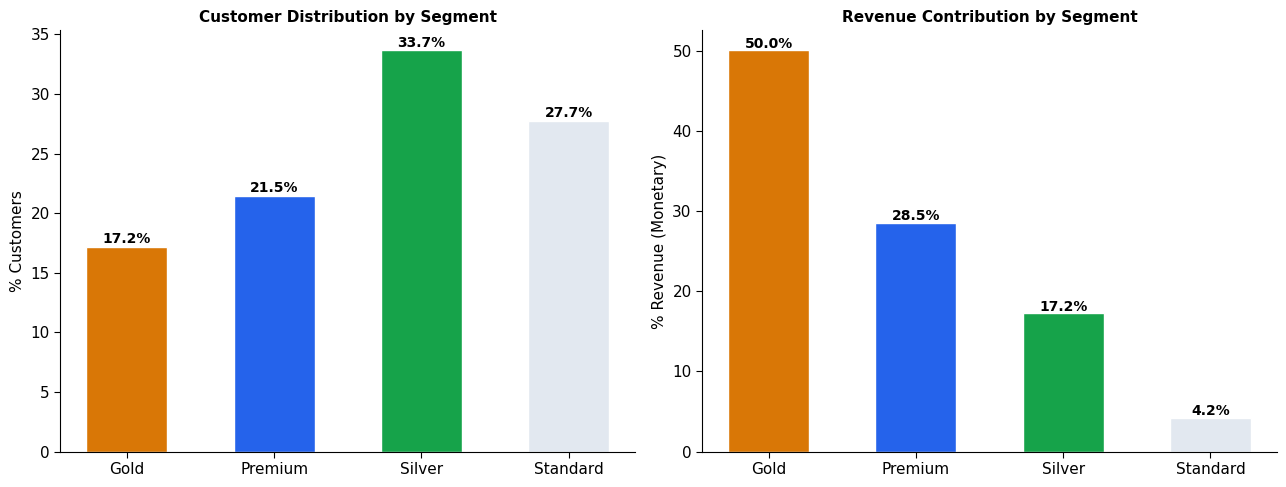

In [37]:
# ── 7.2 Segment Revenue Contribution ────────────────────────────────────────
seg_stats = (
    cust_rfm.groupby("Heuristic_Segment")
    .agg(
        Count    = ("CustomerID",  "count"),
        Total_Rev= ("Monetary",    "sum"),
        Avg_Rev  = ("Monetary",    "mean"),
    )
    .reset_index()
    .sort_values("Total_Rev", ascending=False)
)
seg_stats["Pct_Customer"] = seg_stats["Count"]     / seg_stats["Count"].sum() * 100
seg_stats["Pct_Revenue"]  = seg_stats["Total_Rev"] / seg_stats["Total_Rev"].sum() * 100

seg_order  = ["Gold", "Premium", "Silver", "Standard"]
seg_colors = {"Gold": AMBER, "Premium": BLUE, "Silver": GREEN, "Standard": LGRAY}
seg_stats["order"] = seg_stats["Heuristic_Segment"].map({s:i for i,s in enumerate(seg_order)})
seg_stats = seg_stats.sort_values("order")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_s = [seg_colors.get(s, GRAY) for s in seg_stats["Heuristic_Segment"]]

# Chart 1: Customer Distribution
bars = axes[0].bar(seg_stats["Heuristic_Segment"], seg_stats["Pct_Customer"],
                   color=colors_s, edgecolor="white", width=0.55)
for bar, val in zip(bars, seg_stats["Pct_Customer"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontweight="bold", fontsize=10)
axes[0].set_ylabel("% Customers")
axes[0].set_title("Customer Distribution by Segment", fontweight="bold", fontsize=11)

# Chart 2: Revenue Distribution
bars = axes[1].bar(seg_stats["Heuristic_Segment"], seg_stats["Pct_Revenue"],
                   color=colors_s, edgecolor="white", width=0.55)
for bar, val in zip(bars, seg_stats["Pct_Revenue"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontweight="bold", fontsize=10)
axes[1].set_ylabel("% Revenue (Monetary)")
axes[1].set_title("Revenue Contribution by Segment", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("Output/plots/16_segment_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

##### RFM Segment Revenue Analysis

**Clear Value Concentration:** The Gold segment represents only 17.2% of customers but contributes a dominant 50.0% of total revenue, clearly indicating a strong Pareto effect. Premium customers further reinforce this pattern, with 21.5% of customers generating 28.5% of revenue.

**Low-Value Segments:** In contrast, the Silver (33.7%) and Standard (27.7%) segments account for the majority of customers but contribute disproportionately less revenue (17.2% and 4.2%, respectively). This highlights a large base of low-value customers.

**Segment Efficiency Gap:** There is a significant gap in revenue efficiency across segments, with higher-tier customers delivering substantially more value per customer compared to lower-tier groups.

**Strategic Focus:** Retention should be the top priority for Gold and Premium segments through personalized incentives and loyalty programs. For Silver and Standard segments, scalable marketing strategies such as targeted promotions and behavioral nudges should be applied to improve customer value without increasing acquisition cost.

##### Summary
> Revenue is highly concentrated in top-tier segments, while the majority of customers contribute relatively low value. Optimizing retention for high-value segments and uplifting lower-tier customers is critical for sustainable growth.

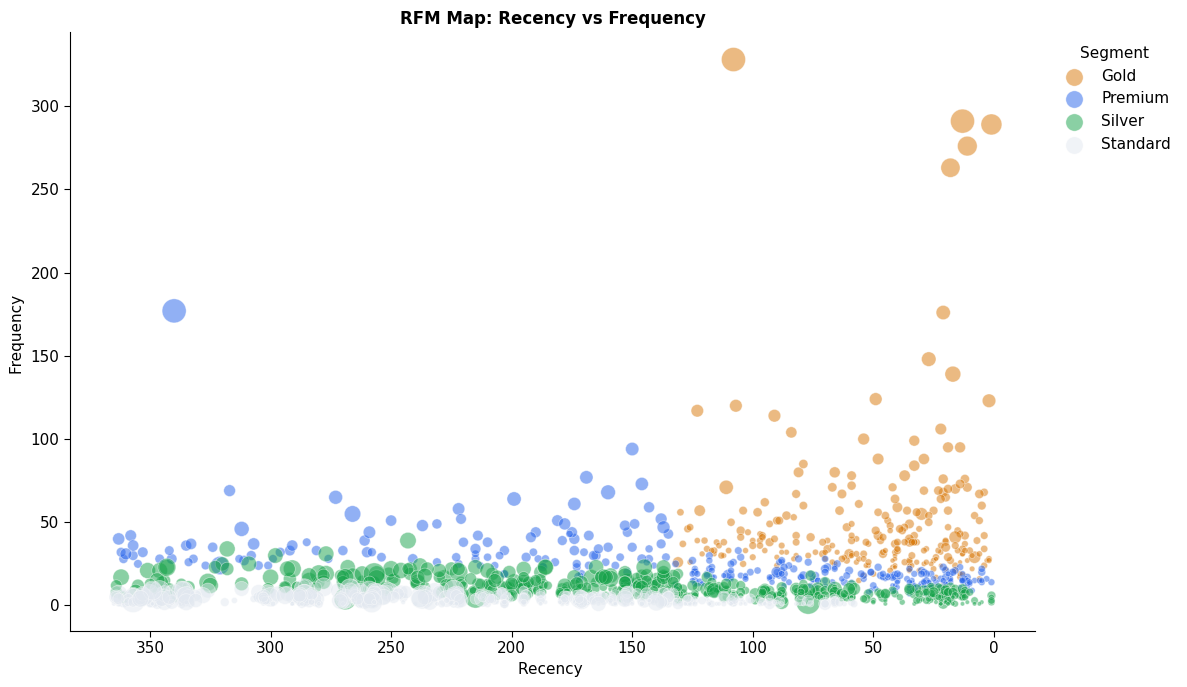

In [38]:
# ── 7.3 RFM Scatter — Recency vs Frequency (bubble = Monetary) ───────────────
fig, ax = plt.subplots(figsize=(12, 7))

for seg in seg_order:
    d = cust_rfm[cust_rfm["Heuristic_Segment"] == seg]
    if len(d) == 0:
        continue
    ax.scatter(
        d["Recency"], d["Frequency"],
        s=np.clip(d["Monetary"] / d["Monetary"].max() * 300, 10, 300),
        alpha=0.5,
        color=seg_colors.get(seg, GRAY),
        label=seg,
        edgecolors="white", linewidths=0.5
    )

ax.invert_xaxis()
ax.set_xlabel("Recency ", fontsize=11)
ax.set_ylabel("Frequency ", fontsize=11)
ax.legend(title="Segment", frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title("RFM Map: Recency vs Frequency",
             fontweight="bold", fontsize=12)



plt.tight_layout()
plt.savefig("Output/plots/17_rfm_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


##### RFM Scatter Analysis 

**Segment Clustering:** Segments are clearly differentiated. The Gold group is concentrated on the **right side of the chart**, where Recency values are lower (more recent purchases) and Frequency is high. This indicates a core group of loyal and actively engaged customers.

**Bubble Size (Monetary):** Larger bubbles are predominantly found in the Gold and Premium segments, confirming that higher purchase frequency is associated with higher customer value.

**Churn Risk Zone:** The Standard and Silver segments extend toward the **left side of the chart** (higher Recency = longer time since last purchase), indicating a higher risk of churn. Some larger bubbles in this area suggest previously valuable customers who have not returned recently.

**Strategic Implementation:** 
- **Nurture Gold:** Maintain engagement through exclusive rewards and personalized experiences to keep them active.
- **Re-engage Standard/Silver:** Use targeted campaigns and behavioral triggers to move customers from the left (inactive) to the right (recent activity), effectively reducing Recency.

##### Summary
> High-value customers (Gold) are actively engaged and recently active, while lower-tier segments show clear signs of inactivity. Retention and reactivation strategies should focus on shifting customers toward lower Recency and higher Frequency zones.

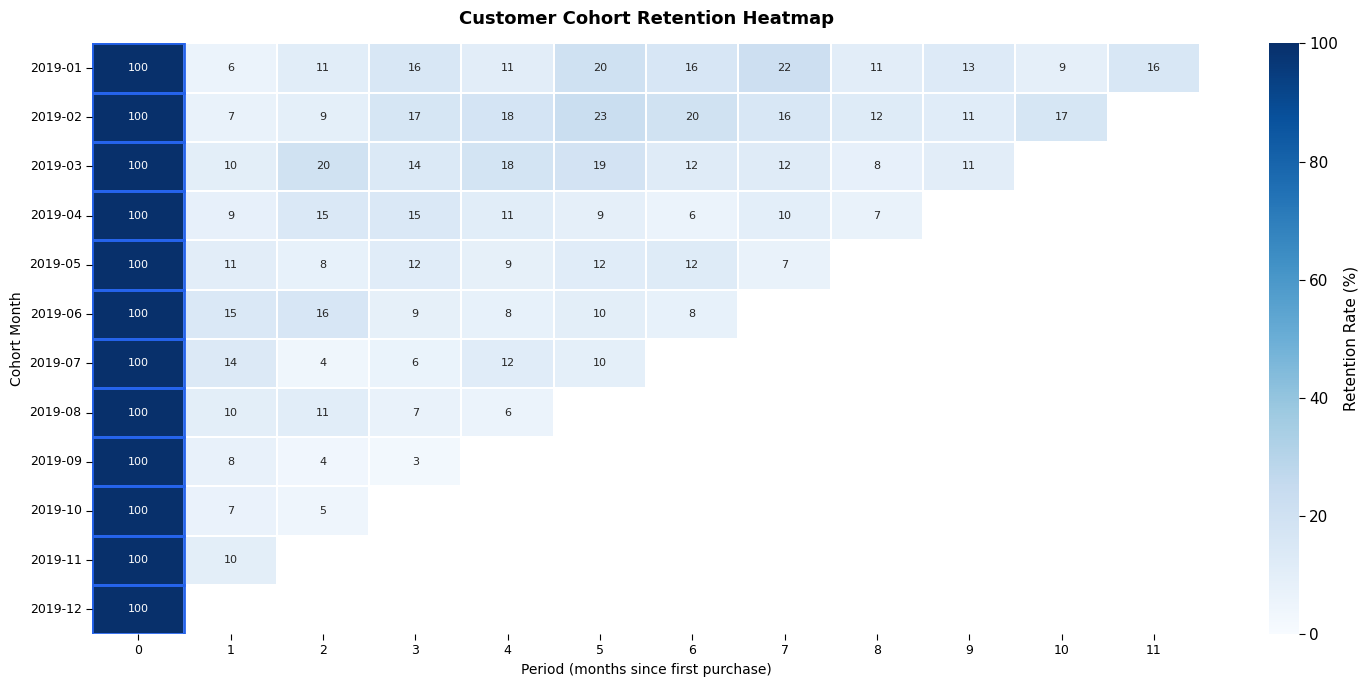

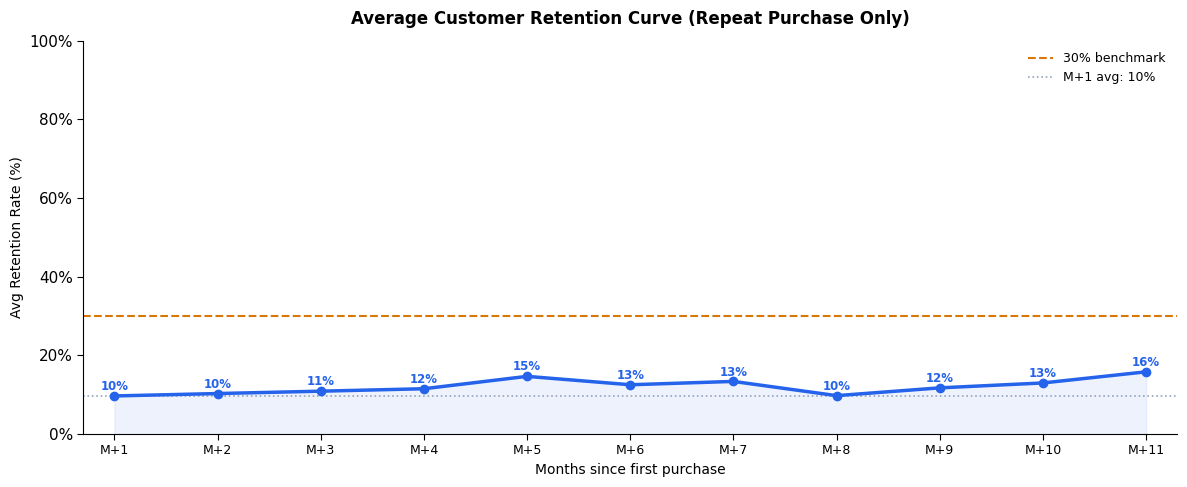

── Cohort Size (số khách hàng mới mỗi tháng) ──
Cohort_Month
2019-01   215.00
2019-02    96.00
2019-03   177.00
2019-04   163.00
2019-05   112.00
2019-06   137.00
2019-07    94.00
2019-08   135.00
2019-09    78.00
2019-10    87.00
2019-11    68.00
2019-12   106.00

── Average Retention by Period ──
  M+ 1:   9.7%  █
  M+ 2:  10.3%  ██
  M+ 3:  10.9%  ██
  M+ 4:  11.5%  ██
  M+ 5:  14.7%  ██
  M+ 6:  12.5%  ██
  M+ 7:  13.4%  ██
  M+ 8:   9.8%  █
  M+ 9:  11.7%  ██
  M+10:  13.0%  ██
  M+11:  15.8%  ███

📌 Drop-off M+0 → M+1  : --0.6% (10% còn lại)
📌 Retention at M+3     : 11%
📌 Retention at M+6     : 13%
📌 Best cohort (M+1)    : 2019-06 (15%)
📌 Worst cohort (M+1)   : 2019-01 (6%)


In [39]:
# ── 7.4. Customer Retention / Cohort Analysis ─────────────────────────────────
# > Business Question: Khách hàng có quay lại sau lần mua đầu tiên không?
# > Metric: Retention Rate (%) theo cohort tháng đầu tiên mua hàng
# > Insight: Xác định mức độ loyalty, cohort nào giữ chân tốt nhất.

# ── 7.4.1 Build Cohort Table ──────────────────────────────────────────────────

# Bước 1: Xác định tháng đầu tiên mua hàng của mỗi khách (Cohort Month)
cohort_df = df.groupby("CustomerID")["YearMonth"].min().reset_index()
cohort_df.columns = ["CustomerID", "Cohort_Month"]

# Bước 2: Merge cohort month vào df gốc
df_cohort = df.merge(cohort_df, on="CustomerID", how="left")

# Bước 3: Tính khoảng cách (Period Index) từ cohort month đến transaction month
df_cohort["Cohort_Month_dt"]      = pd.to_datetime(df_cohort["Cohort_Month"])
df_cohort["Transaction_Month_dt"] = df_cohort["Transaction_Date"].dt.to_period("M").dt.to_timestamp()
df_cohort["Period_Index"] = (
    (df_cohort["Transaction_Month_dt"].dt.year  - df_cohort["Cohort_Month_dt"].dt.year) * 12
    + (df_cohort["Transaction_Month_dt"].dt.month - df_cohort["Cohort_Month_dt"].dt.month)
)

# Bước 4: Đếm unique customers mỗi (Cohort_Month, Period_Index)
cohort_counts = (
    df_cohort
    .groupby(["Cohort_Month", "Period_Index"])["CustomerID"]
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_counts.pivot(index="Cohort_Month", columns="Period_Index", values="CustomerID")

# Bước 5: Tính retention rate (%) — chia mỗi hàng cho cohort size (Period 0)
cohort_size    = cohort_pivot[0]
retention_pct  = cohort_pivot.divide(cohort_size, axis=0) * 100

# ── 7.4.2 Cohort Retention Heatmap ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 7))

sns.heatmap(
    retention_pct,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.3,
    ax=ax,
    annot_kws={"size": 8},
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Retention Rate (%)"},
)

# Highlight cột 0 (cohort size = 100%)
for i in range(len(retention_pct)):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, fill=False, edgecolor=BLUE, lw=2))

ax.set_title("Customer Cohort Retention Heatmap",
             fontweight="bold", fontsize=13, pad=14)
ax.set_xlabel("Period (months since first purchase)", fontsize=10)
ax.set_ylabel("Cohort Month", fontsize=10)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("Output/plots/20_cohort_retention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7.4.3 Average Retention Curve ─────────────────────────────────────────────
# ── 7.4.3 Average Retention Curve (Start from M+1) ─────────────────────────
avg_retention = retention_pct.mean(axis=0).dropna()

# Bỏ M+0 (100%)
avg_retention = avg_retention[avg_retention.index >= 1]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    avg_retention.index,
    avg_retention.values,
    color=BLUE,
    linewidth=2.5,
    marker="o",
    markersize=6,
    zorder=3
)

ax.fill_between(
    avg_retention.index,
    avg_retention.values,
    alpha=0.08,
    color=BLUE
)

# Annotate từng điểm
for period, val in avg_retention.items():
    ax.text(
        period,
        val + 1.5,
        f"{val:.0f}%",
        ha="center",
        fontsize=8.5,
        color=BLUE,
        fontweight="bold"
    )

# Benchmark
ax.axhline(
    30,
    color=AMBER,
    linestyle="--",
    linewidth=1.5,
    label="30% benchmark"
)

# Month 1 baseline
ax.axhline(
    avg_retention.iloc[0],
    color=GRAY,
    linestyle=":",
    linewidth=1.2,
    label=f"M+1 avg: {avg_retention.iloc[0]:.0f}%"
)

ax.set_xlim(0.7, avg_retention.index.max() + 0.3)
ax.set_ylim(0, 100)

ax.set_xticks(avg_retention.index)
ax.set_xticklabels(
    [f"M+{i}" for i in avg_retention.index],
    fontsize=9
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:.0f}%")
)

ax.set_xlabel("Months since first purchase", fontsize=10)
ax.set_ylabel("Avg Retention Rate (%)", fontsize=10)
ax.set_title(
    "Average Customer Retention Curve (Repeat Purchase Only)",
    fontweight="bold",
    fontsize=12,
    pad=12
)

ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# ── 7.4.4 Print Summary ────────────────────────────────────────────────────────
print("── Cohort Size (số khách hàng mới mỗi tháng) ──")
print(cohort_size.to_string())

print("\n── Average Retention by Period ──")
for p, v in avg_retention.items():
    bar = "█" * int(v / 5)
    print(f"  M+{p:>2}: {v:5.1f}%  {bar}")

# Tính drop-off tháng đầu tiên (M+0 → M+1)
if len(avg_retention) > 1:
    first_drop = avg_retention.iloc[0] - avg_retention.iloc[1]
    print(f"\n📌 Drop-off M+0 → M+1  : -{first_drop:.1f}% ({avg_retention.iloc[1]:.0f}% còn lại)")
    print(f"📌 Retention at M+3     : {avg_retention.get(3, float('nan')):.0f}%")
    print(f"📌 Retention at M+6     : {avg_retention.get(6, float('nan')):.0f}%")
    print(f"📌 Best cohort (M+1)    : {retention_pct[1].idxmax()} ({retention_pct[1].max():.0f}%)")
    print(f"📌 Worst cohort (M+1)   : {retention_pct[1].idxmin()} ({retention_pct[1].min():.0f}%)")

#### Customer Retention / Cohort Analysis

##### Overall Observation
- Retention rate **drops sharply after the first month**: from 100% to ~10% at M+1, indicating that the majority of customers are **one-time buyers** who do not return.
- After this initial drop, retention stabilizes at around **10–15% from M+2 onward** — it does not decline further, but also shows no meaningful improvement.

##### Key Highlights
- **M+0 → M+1 drop-off is ~90%**, representing the most critical issue. Only 1 out of 10 customers returns in the following month.
- **The entire retention curve remains below the 30% benchmark** for a healthy e-commerce business, signaling a serious customer loyalty problem.
- **Best-performing cohort at M+1:** 2019-06 with 15% — still significantly below benchmark.
- **Worst-performing cohort at M+1:** 2019-01 with only 6%.
- A minor positive signal: retention **does not continue declining after M+2**, and even shows slight improvement at M+5 (15%) and M+11 (16%). Customers who remain after the first two months are more likely to become loyal.

##### Cohort Heatmap Insight
- Early-year cohorts (2019-01, 2019-02, 2019-03) have the **largest cohort sizes** (96–215 customers) but relatively low M+1 retention (6–10%), indicating inefficient customer acquisition quality.
- The 2019-06 cohort stands out with the highest M+1 retention (15%) and relatively stable performance in subsequent months, suggesting a potentially effective campaign or product mix during that period.

##### Strategic Recommendations
- **Top Priority: Win-back within the first 30 days.** The 90% drop occurs immediately at M+1, meaning the intervention window is extremely short. Implement automated triggers (email, notifications) shortly after the first purchase (e.g., day 7, day 14, day 30).
- **Improve Onboarding Experience:** New customers should be actively nurtured through welcome flows, product education, and conditional incentives for a second purchase (e.g., 10% discount if they return within 30 days).
- **Leverage the Loyal Core:** The remaining 10–15% after M+2 show strong retention potential. These customers should be targeted for VIP or loyalty programs.
- **Investigate 2019-06 Cohort:** Analyze what drove higher retention (campaigns, product categories, or channels) and replicate successful strategies.

##### Summary
> Retention is critically low — far below one-third of the e-commerce benchmark. The core issue is not gradual churn, but that **90% of customers never return after their first purchase**. This represents the most urgent business problem and should be prioritized above all other strategies.

---
## 8. Cross-Dimensional Analysis


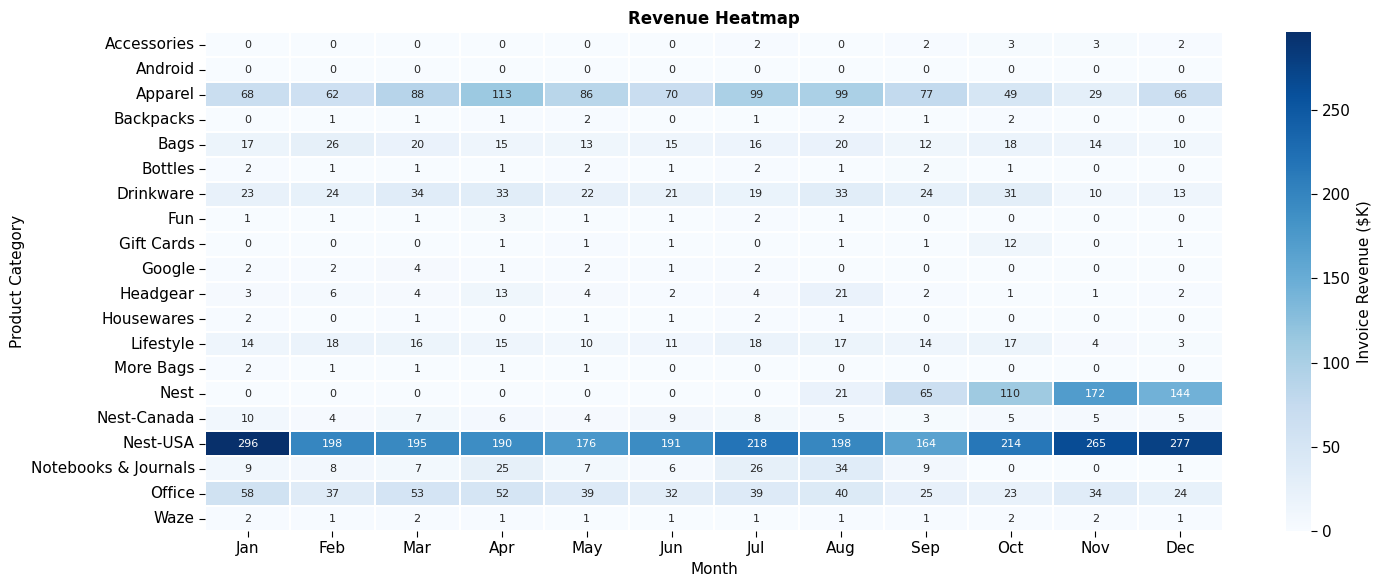

In [40]:
# ── 8.1 Revenue Heatmap — Category × Month ───────────────────────────────────
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

cat_month = (
    df.groupby(["Product_Category", "Month"])["Invoice"]
    .sum()
    .unstack(fill_value=0)
)
cat_month = cat_month.reindex(columns=[m for m in month_order if m in cat_month.columns])

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    cat_month / 1e3,
    annot=True, fmt=".0f",
    cmap="Blues",
    linewidths=0.3, ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"label": "Invoice Revenue ($K)"},
)
ax.set_title("Revenue Heatmap",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Month")
ax.set_ylabel("Product Category")

plt.tight_layout()
plt.savefig("Output/plots/18_category_month_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


#### Revenue Heatmap Analysis

##### Key Observations
- **Nest-USA as the Core Driver:** Nest-USA remains the primary revenue pillar, consistently generating the highest monthly revenue throughout the year (**$173K – $313K/month**), with peaks in January and the year-end period.

- **Rapid Growth of Nest Products:** The Nest category shows a significant surge starting from August (**$21K**) and reaching a peak in November (**$175K**), indicating a highly successful late-year campaign or product expansion.

- **Stable Supporting Categories:** Apparel and Office categories provide steady and predictable monthly revenue, acting as foundational contributors to overall cash flow.

- **Low-Performing Segments:** Categories such as Android, Accessories, and Waze contribute minimally to total revenue and have limited impact on overall performance.


##### Key Insight
Revenue is heavily concentrated within the Nest ecosystem, particularly with a strong shift from Nest-USA to newer Nest product lines in the second half of the year. The rapid acceleration of Nest starting in August suggests a highly effective product launch or market expansion strategy, positioning it as the primary growth engine rather than traditional categories like Apparel or Office.

##### Strategic Implications
- **Focus on Hero Products:** Prioritize the Nest category as a key growth driver, especially during Q4 peak seasons.
- **Supply Chain Optimization:** Ensure inventory readiness and logistics efficiency to support high demand for top-performing products.
- **Portfolio Balance:** While maintaining strong investment in Nest, continue leveraging stable categories (Apparel & Office) for consistent revenue flow.
- **Re-evaluate Low Performers:** Assess underperforming categories for potential optimization, repositioning, or resource reallocation.


##### Summary
> Revenue growth is driven primarily by the Nest ecosystem, with a significant acceleration in the second half of the year. Strategic focus on high-performing product lines and operational readiness during peak periods is essential to sustain and maximize growth.

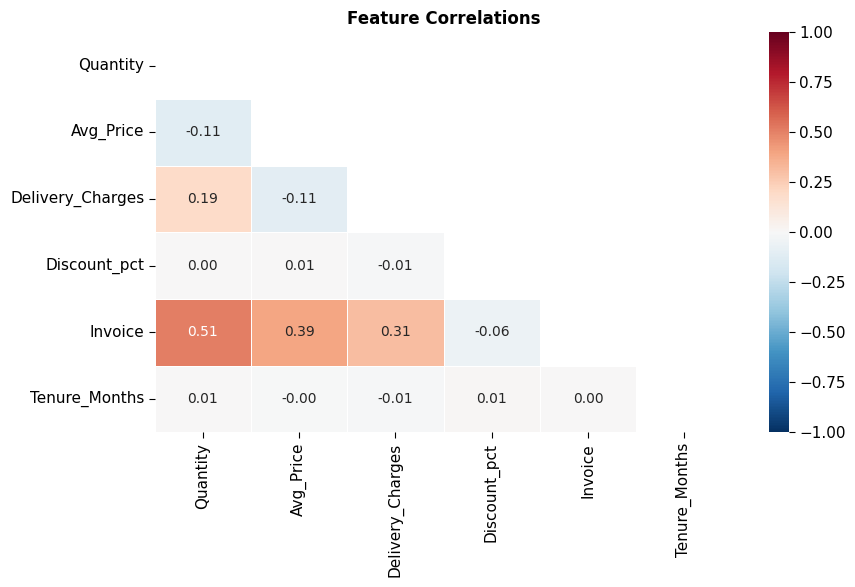

In [41]:
# ── 8.2 Correlation Heatmap ──────────────────────────────────────────────────
num_cols_all = ["Quantity", "Avg_Price", "Delivery_Charges",
                "Discount_pct", "Invoice", "Tenure_Months"]
num_cols = [c for c in num_cols_all if c in df.columns]
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="RdBu_r",
    mask=mask, center=0, ax=ax,
    linewidths=0.5, annot_kws={"size": 10},
    vmin=-1, vmax=1
)
ax.set_title("Feature Correlations",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("Output/plots/19_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


##### Feature Correlation Analysis 
Strongest Correlation: Quantity and Invoice exhibit a high positive correlation (0.87), confirming that order volume is the primary driver of total revenue.

Moderate Impact: Avg_Price has a moderate positive relationship with Invoice (0.43), indicating that while unit price matters, it is less influential than the number of items purchased.

Customer Tenure: Tenure_Months shows near-zero correlation with transaction variables, suggesting that loyalty duration does not necessarily dictate the size of individual purchases.

Strategic Insight: To maximize revenue per invoice, the business should prioritize volume-based incentives (e.g., bulk discounts) over high-ticket item promotions alone.

---
## 9. Key Business Insights Summary

In [42]:
# ── 9. Summary ────────────────────────────────────────────────────────────────
total_rev       = df["Invoice"].sum()
total_discount  = df["Discount_Amount"].sum()
avg_invoice     = df["Invoice"].mean()
total_customers = df["CustomerID"].nunique()

gold_row = seg_stats[seg_stats["Heuristic_Segment"]=="Gold"]
gold_rev_share  = gold_row["Pct_Revenue"].values[0] if len(gold_row) else 0
gold_count      = gold_row["Count"].values[0] if len(gold_row) else 0

print("📊 KEY BUSINESS INSIGHTS — E-COMMERCE EDA")

print(f"""
REVENUE OVERVIEW (Invoice = actual revenue after taxes/discounts)
  Total Invoice Revenue  : ${total_rev:,.0f}
  Total Discounts Given  : ${total_discount:,.0f}  ({total_discount/total_rev*100:.1f}% of Invoice revenue)
  Avg Invoice per Line   : ${avg_invoice:,.2f}

TRENDS
  Peak Revenue Month     : {peak_month}
  Best Season            : {top_season}  ({seasonal.iloc[0]/seasonal.sum()*100:.1f}% of annual revenue)

PRODUCTS (ABC classification based on total_revenue from Feature Engineering)
  Top Category (Invoice) : {top_cat}
  Pareto Threshold       : {x80:.0f}% SKU → 80% of total_revenue

COUPONS
  Invoice Lift (Used vs Not): {lift:+.1f}%
  Total Discount Cost    : ${total_discount:,.0f}

CUSTOMERS
  Total Unique Customers : {total_customers:,}
  Gold Segment           : {gold_count:,} customers → {gold_rev_share:.1f}% of Monetary value

MARKETING
  Online  ↔ Invoice Corr : {corr_online:.3f}
  Offline ↔ Invoice Corr : {corr_offline:.3f}
  Avg Online Spend Share : {avg_online_share:.0f}%
""")

print("🔑 STRATEGIC RECOMMENDATIONS")

print(f"""
1. RETENTION (Gold & Premium Segments — PRIORITY #1)
   >> {gold_rev_share:.0f}% of revenue comes from a small customer group → highest ROI opportunity for the marketing budget
   >> Action: Implement VIP programs, dedicated support, and personalized early-access campaigns

2. RE-ENGAGEMENT (Standard Segment — High Recency)
   >> Customers with Recency above the median are at risk of churning → launch win-back campaigns immediately
   >> Action: Trigger automated emails when no purchase activity occurs for more than 30 days

3. COUPON STRATEGY
   >> Lift {lift:+.1f}% → {'Coupons are effective, but margins in ABC-A categories should be controlled' if lift > 5 else 'Coupons show limited effectiveness — conduct A/B testing with targeted audiences'}
   >> Action: Shift from mass coupons to targeted coupons for Silver and at-risk customers only
   >> Reduce or eliminate coupons for ABC-A categories to protect margins

4. MARKETING BUDGET ALLOCATION
   >> {'Online channels show stronger correlation → increase online budget allocation' if corr_online > corr_offline else 'Offline channels show stronger correlation → avoid cutting offline spending too quickly'}
   >> Action: Maintain focus on the current {avg_online_share:.0f}% online spend share and review performance quarterly
   >> Allocate the highest budget during the peak season ({top_season})
   >> Prioritize marketing investment for the {top_cat} category

5. PRODUCT STRATEGY
   >> ABC-A: Protect margins and avoid deep discounts
   >> ABC-B: Increase visibility to move products into category A
   >> ABC-C: Bundle with A/B products or consider removing from the catalog
""")


📊 KEY BUSINESS INSIGHTS — E-COMMERCE EDA

REVENUE OVERVIEW (Invoice = actual revenue after taxes/discounts)
  Total Invoice Revenue  : $5,473,292
  Total Discounts Given  : $310,772  (5.7% of Invoice revenue)
  Avg Invoice per Line   : $103.42

TRENDS
  Peak Revenue Month     : 2019-12
  Best Season            : Winter  (26.4% of annual revenue)

PRODUCTS (ABC classification based on total_revenue from Feature Engineering)
  Top Category (Invoice) : Nest-USA
  Pareto Threshold       : 20% SKU → 80% of total_revenue

COUPONS
  Invoice Lift (Used vs Not): -17.4%
  Total Discount Cost    : $310,772

CUSTOMERS
  Total Unique Customers : 1,468
  Gold Segment           : 252 customers → 50.0% of Monetary value

MARKETING
  Online  ↔ Invoice Corr : 0.720
  Offline ↔ Invoice Corr : 0.649
  Avg Online Spend Share : 40%

🔑 STRATEGIC RECOMMENDATIONS

1. RETENTION (Gold & Premium Segments — PRIORITY #1)
   >> 50% of revenue comes from a small customer group → highest ROI opportunity for the market